## Proyecto Final — Minería de Datos  
## Clasificación de Diabetes · Pima Indians Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.impute import KNNImputer
from scipy import stats
from scipy.stats import shapiro, spearmanr, pearsonr, chi2_contingency, mannwhitneyu
from scipy.spatial.distance import mahalanobis

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, classification_report
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

IMAGE_DIR = Path('Image')
IMAGE_DIR.mkdir(exist_ok=True)


def guardar_figura(nombre, fig=None, dpi=300):
    fig = fig or plt.gcf()
    ruta = IMAGE_DIR / f'{nombre}.png'
    fig.savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'Imagen guardada: {ruta}')
    return ruta


---
## BLOQUE 1 — Estadística Descriptiva y Exploratoria
### Paso 1 · Cargar datos y revisar el diccionario de variables

In [2]:
df_train = pd.read_csv('Training.csv')
df_test  = pd.read_csv('Testing.csv')

n_original = len(df_train)
df_train = df_train.drop_duplicates().reset_index(drop=True)
print(f'Training : {n_original} filas | {n_original - len(df_train)} duplicadas eliminadas | {len(df_train)} filas finales')
print(f'Testing  : {df_test.shape[0]} filas x {df_test.shape[1]} columnas | {df_test.duplicated().sum()} duplicadas')
df_train.head(8)


Training : 2460 filas | 0 duplicadas eliminadas | 2460 filas finales
Testing  : 308 filas x 9 columnas | 0 duplicadas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,151.0000,NaN,NaN,NaN,34.5000,0.8900,27,1
1,1,91.0000,65.0000,14.0000,123.0000,22.5000,0.4610,22,0
2,4,139.0000,87.0000,41.0000,155.0000,40.1000,0.6740,35,1
3,1,118.0000,58.0000,36.0000,94.0000,33.3000,0.2610,23,0
4,0,132.0000,69.0000,18.0000,131.0000,24.6000,0.1780,23,0
5,0,106.0000,62.0000,31.0000,72.0000,36.0000,0.7070,24,1
6,1,181.0000,78.0000,42.0000,293.0000,40.0000,1.2580,22,1
7,5,107.0000,79.0000,34.0000,NaN,38.4000,0.2780,36,0


In [3]:
# Diccionario de variables
diccionario = pd.DataFrame({
    'Variable'   : df_train.columns,
    'Rol'        : ['Input']*8 + ['Output'],
    'Tipo'       : ['Cuantitativa discreta', 'Cuantitativa continua', 'Cuantitativa continua',
                    'Cuantitativa continua', 'Cuantitativa continua', 'Cuantitativa continua',
                    'Cuantitativa continua', 'Cuantitativa discreta', 'Cualitativa binaria'],
    'Descripción': ['Número de embarazos', 'Nivel de Glucosa en sangre',
                    'Nivel de Presión arterial', 'Grosor de la piel(mm)',
                    'Nivel de insulina en Sangre', 'Índice de masa corporal',
                    'Función de antecedentes familiares (score genético)', 'Edad (años)',
                    '0=Sin diabetes · 1=Con diabetes']
})
diccionario

,Variable,Rol,Tipo,Descripción
0,Pregnancies,Input,Cuantitativa discreta,Número de embarazos
1,Glucose,Input,Cuantitativa continua,Nivel de Glucosa en sangre
2,BloodPressure,Input,Cuantitativa continua,Nivel de Presión arterial
3,SkinThickness,Input,Cuantitativa continua,Grosor de la piel(mm)
4,Insulin,Input,Cuantitativa continua,Nivel de insulina en Sangre
5,BMI,Input,Cuantitativa continua,Índice de masa corporal
6,DiabetesPedigreeFunction,Input,Cuantitativa continua,Función de antecedentes familiares (score gené...
7,Age,Input,Cuantitativa discreta,Edad (años)
8,Outcome,Output,Cualitativa binaria,0=Sin diabetes · 1=Con diabetes


In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2460 non-null   int64  
 1   Glucose                   2442 non-null   float64
 2   BloodPressure             2380 non-null   float64
 3   SkinThickness             1710 non-null   float64
 4   Insulin                   1211 non-null   float64
 5   BMI                       2431 non-null   float64
 6   DiabetesPedigreeFunction  2460 non-null   float64
 7   Age                       2460 non-null   int64  
 8   Outcome                   2460 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 173.1 KB


### Paso 2 · Análisis Univariado
Media, mediana, moda, IQR, CV, asimetría y curtosis para cada variable.

In [5]:
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

# Estas columnas pueden traer faltantes como NaN o como ceros biológicamente imposibles.
# Para el EDA se excluyen del cálculo y no distorsionan los estadísticos.
cols_ceros_eda = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_uni = df_train.copy()
df_uni[cols_ceros_eda] = df_uni[cols_ceros_eda].replace(0, np.nan)

stats_uni = pd.DataFrame(index=features)
stats_uni['Media']     = df_uni[features].mean()
stats_uni['Mediana']   = df_uni[features].median()
stats_uni['Moda']      = df_uni[features].mode(dropna=True).iloc[0]
stats_uni['Q1']        = df_uni[features].quantile(0.25)
stats_uni['Q3']        = df_uni[features].quantile(0.75)
stats_uni['IQR']       = stats_uni['Q3'] - stats_uni['Q1']
stats_uni['CV (%)']    = (df_uni[features].std() / df_uni[features].mean() * 100).round(2)
stats_uni['Asimetría'] = df_uni[features].skew()
stats_uni['Curtosis']  = df_uni[features].kurtosis()

print('Estadística Univariada (faltantes excluidos):')
stats_uni.style.background_gradient(cmap='Blues', subset=['Media','Mediana'])               .format('{:.3f}')


Estadística Univariada (faltantes excluidos):


,Media,Mediana,Moda,Q1,Q3,IQR,CV (%),Asimetría,Curtosis
Pregnancies,3.809,3.000,2.000,1.000,6.000,5.000,78.580,0.928,0.429
Glucose,122.145,118.000,111.000,101.000,140.000,39.000,22.490,0.517,-0.285
BloodPressure,72.372,72.000,70.000,66.000,79.000,13.000,14.240,0.064,0.897
SkinThickness,28.418,29.000,30.000,22.000,35.000,13.000,32.590,0.169,-0.246
Insulin,146.548,121.000,49.000,72.500,180.000,107.500,74.980,2.228,6.881
BMI,32.510,32.400,32.900,28.100,36.100,8.000,19.030,0.487,0.482
DiabetesPedigreeFunction,0.477,0.402,0.261,0.264,0.598,0.334,62.110,1.931,5.728
Age,32.699,30.000,22.000,24.000,39.000,15.000,31.610,1.159,0.880


# CONCLUSIONES A PARTIR DE ESTA TABLA
> Nota: los estadísticos se calcularon **excluyendo los ceros biológicamente imposibles** de Glucose, BloodPressure, SkinThickness, Insulin y BMI (su tratamiento se documenta en el Bloque 2).

1. Insulina: extremadamente variable → posibles outliers o pacientes muy distintos metabólicamente. Podríamos aplicar transformaciones
2. Hay pocos valores muy altos que están jalando la media hacia arriba, asimetría a la derecha.
3. Insulina está fuertemente sesgada comparando la media con la mediana.
4. En Insulin, DiabetesPedigreeFunction y BloodPressure hay presencia de valores extremos importantes (IQR alto + Curtosis alta = outliers)
5. Glucose es la variable más equilibrada (baja asimetría, Media ≈ mediana, CV moderado)

Imagen guardada: Image\01_outcome_distribucion.png


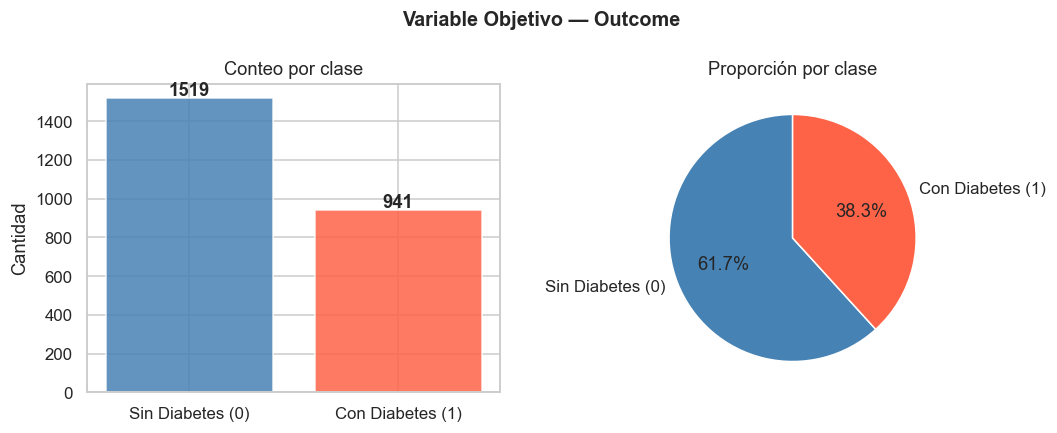

In [6]:
# Distribución de la variable objetivo
conteo = df_train['Outcome'].value_counts()
labels = ['Sin Diabetes (0)', 'Con Diabetes (1)']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, conteo, color=['steelblue','tomato'], alpha=0.85)
axes[0].set_title('Conteo por clase')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(conteo):
    axes[0].text(i, v+15, str(v), ha='center', fontweight='bold')
axes[1].pie(conteo, labels=labels, autopct='%1.1f%%',
            colors=['steelblue','tomato'], startangle=90)
axes[1].set_title('Proporción por clase')
plt.suptitle('Variable Objetivo — Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
guardar_figura('01_outcome_distribucion', fig)
plt.show()

### Paso 3 · Visualización Exploratoria
Histogramas y boxplots para cuantitativas; el pie plot para la variable objetivo ya fue mostrado.

Imagen guardada: Image\02_histogramas_por_clase.png


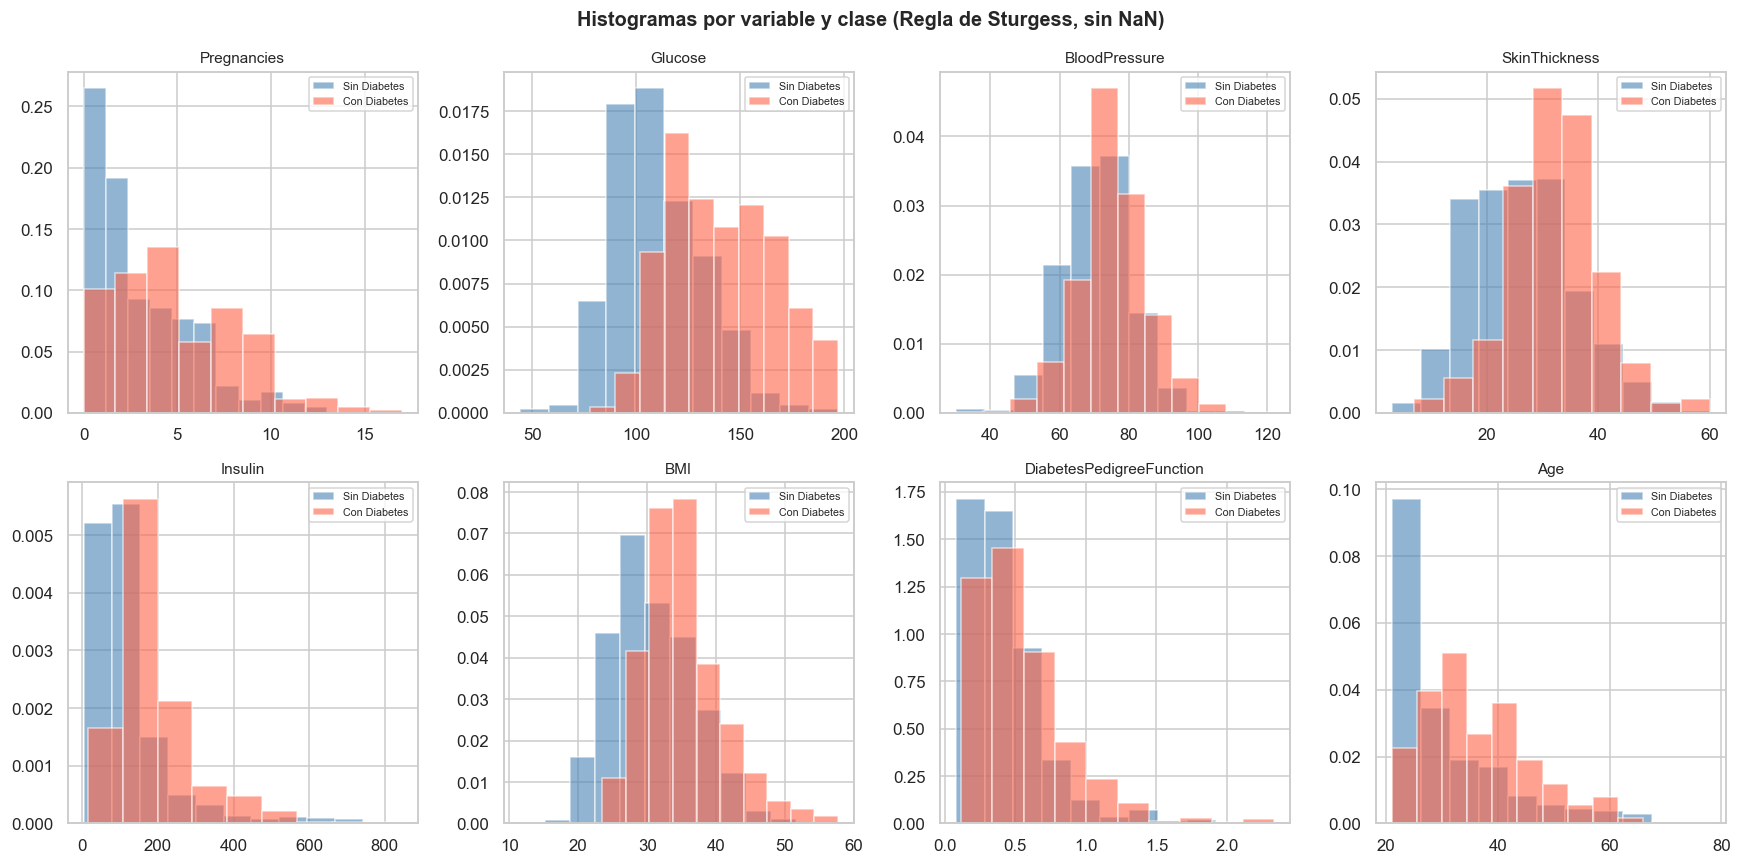

In [7]:
# Histogramas por variable y clase
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), features):
    for val, color, label in [(0,'steelblue','Sin Diabetes'), (1,'tomato','Con Diabetes')]:
        datos = df_train.loc[df_train['Outcome'] == val, col].dropna()
        if datos.empty:
            continue
        n_bins = max(1, int(1 + 3.322 * np.log10(len(datos))))  # Regla de Sturgess
        ax.hist(datos, bins=n_bins, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Histogramas por variable y clase (Regla de Sturgess, sin NaN)', fontsize=13, fontweight='bold')
plt.tight_layout()
guardar_figura('02_histogramas_por_clase', fig)
plt.show()


El análisis bivariado evidencia que la variable Glucose presenta la mayor capacidad discriminativa entre individuos con y sin diabetes, seguida por BMI y Age, que muestran desplazamientos consistentes hacia valores más altos en la clase positiva. En contraste, variables como BloodPressure y SkinThickness exhiben un alto grado de solapamiento entre clases, lo que sugiere baja relevancia predictiva. Asimismo, la presencia de valores atípicos y concentraciones en cero en variables como Insulin y SkinThickness indica posibles problemas de calidad de datos, lo que requiere tratamiento previo antes de su inclusión en modelos predictivos.

Imagen guardada: Image\03_boxplots_por_clase.png


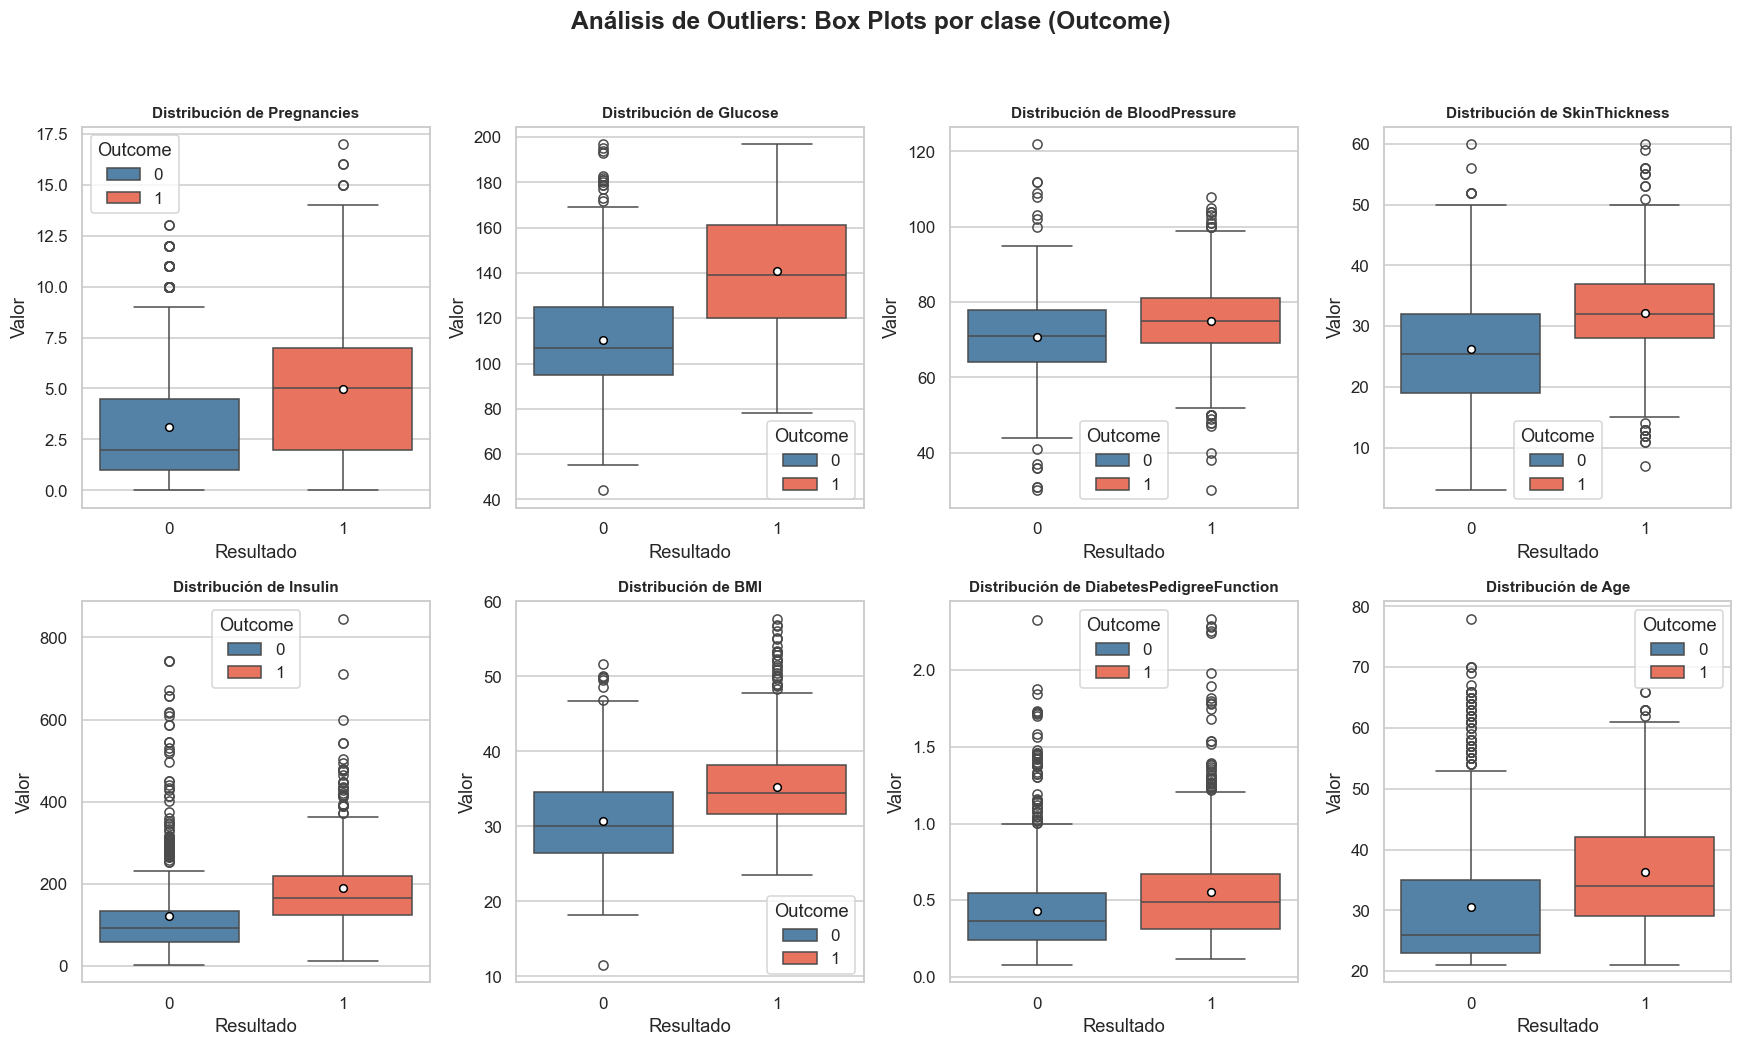

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos la paleta (incluimos números y strings para evitar errores de tipo de dato)
custom_palette = {0: 'steelblue', 1: 'tomato', '0': 'steelblue', '1': 'tomato'}

# Configuración de la figura: 2 filas y 4 columnas
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

for ax, col in zip(axes.flatten(), features):
    sns.boxplot(
        data=df_train,
        x='Outcome',
        y=col,
        hue='Outcome',      # Define el color según la clase
        ax=ax,
        palette=custom_palette,
        showmeans=True,     # Muestra un punto para la media (opcional pero útil)
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"}
    )

    # Estética de cada subgráfico
    ax.set_title(f'Distribución de {col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Resultado')
    ax.set_ylabel('Valor')

# Título principal
plt.suptitle('Análisis de Outliers: Box Plots por clase (Outcome)', fontsize=16, fontweight='bold')

# Ajustar espacio para que no se amontonen las etiquetas
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
guardar_figura('03_boxplots_por_clase', fig)
plt.show()

### Paso 4 · Prueba de Normalidad — Shapiro-Wilk
Determina si cada variable sigue distribución normal para elegir la prueba bivariada correcta según el tipo de comparación.

> El train se verifica sin filas duplicadas (Paso 1) y fue ampliado con datos sintéticos (interpolación entre vecinos de la misma clase). Las pruebas se calculan sobre ese conjunto; como el aumento sintético conserva las distribuciones, los **tamaños de efecto** se mantienen estables.

> **H₀:** la variable se aproxima a distribución normal
> **p-valor < 5%** → Rechazar H₀ → Variable **NO** es normal
> **p-valor ≥ 5%** → No rechazar H₀ → Variable **ES** normal

| Comparación | Normal | No Normal |
|---|---|---|
| Feature vs Feature (multicolinealidad) | Pearson | Spearman |
| Feature vs **Target binario** (Outcome) | Point-Biserial | **Mann-Whitney U** |

> Dado que `Outcome` es una variable **binaria (0/1)**, la comparación correcta con cada feature numérica es **numérica vs categórica**, no numérica vs numérica. Por eso se usa Mann-Whitney U (no Spearman) para medir la relación con el target.

In [9]:
import pandas as pd
from scipy.stats import shapiro

ALPHA = 0.05

# El train no contiene duplicados (verificado al cargar). Para pruebas estadísticas,
# los faltantes se trabajan como NaN aunque el archivo original viniera con ceros.
df_stats = df_train.copy()
df_stats[cols_ceros_eda] = df_stats[cols_ceros_eda].replace(0, np.nan)
print(f'Observaciones para pruebas estadísticas: {len(df_stats)}')

resultados_norm = []

for col in features:
    muestra = df_stats[col].dropna()
    stat, p = shapiro(muestra)

    if p > ALPHA:
        prueba_feat_feat   = 'Pearson'
        prueba_vs_target   = 'Point-Biserial'
    else:
        prueba_feat_feat   = 'Spearman'
        prueba_vs_target   = 'Mann-Whitney U'

    resultados_norm.append({
        'Variable'              : col,
        'n usado'               : len(muestra),
        'Estadístico'           : round(stat, 4),
        'p-valor'               : round(p, 4),
        'Normal?'               : 'SÍ' if p > ALPHA else 'NO',
        'Feat vs Feat'          : prueba_feat_feat,
        'Feat vs Target binario': prueba_vs_target
    })

df_norm = pd.DataFrame(resultados_norm).set_index('Variable')

df_norm.style.map(
    lambda v: 'color:green;font-weight:bold' if v == 'SÍ'
    else ('color:red;font-weight:bold' if v == 'NO' else ''),
    subset=['Normal?']
)


Observaciones para pruebas estadísticas: 2460


,n usado,Estadístico,p-valor,Normal?,Feat vs Feat,Feat vs Target binario
Variable,,,,,,
Pregnancies,2460,0.914800,0.000000,NO,Spearman,Mann-Whitney U
Glucose,2442,0.973100,0.000000,NO,Spearman,Mann-Whitney U
BloodPressure,2380,0.993400,0.000000,NO,Spearman,Mann-Whitney U
SkinThickness,1710,0.992900,0.000000,NO,Spearman,Mann-Whitney U
Insulin,1211,0.801000,0.000000,NO,Spearman,Mann-Whitney U
BMI,2431,0.986000,0.000000,NO,Spearman,Mann-Whitney U
DiabetesPedigreeFunction,2460,0.843200,0.000000,NO,Spearman,Mann-Whitney U
Age,2460,0.886100,0.000000,NO,Spearman,Mann-Whitney U


### Paso 5 · Análisis Bivariado

El análisis bivariado se divide en dos partes con objetivos distintos:

**5a — Heatmap Spearman entre features (multicolinealidad)**  
Detecta si dos predictores están altamente correlacionados entre sí. Se usa Spearman porque ninguna variable es normal (resultado del Paso 4).  
> Correlaciones altas entre features (|r| > 0.7) pueden causar redundancia en el modelo.

**5b — Mann-Whitney U: cada feature vs Outcome (target binario)**  
Compara la distribución de cada variable numérica entre los dos grupos (diabético / no diabético).  
Es el método correcto porque: variables **no normales** + target **binario** → Mann-Whitney U.  
Se complementa con el **rank-biserial (r)** como tamaño de efecto:

| r | Interpretación |
|---|---|
| < 0.1 | Efecto pequeño |
| 0.1 – 0.3 | Efecto moderado |
| ≥ 0.3 | Efecto grande |

> Con n grande, casi cualquier diferencia resulta estadísticamente significativa; por eso el **r** (rank-biserial) es lo que indica qué variables realmente discriminan entre clases.

> **p-valor < 5%** → distribuciones distintas entre clases → variable relevante para el target

Imagen guardada: Image\04_heatmap_spearman.png


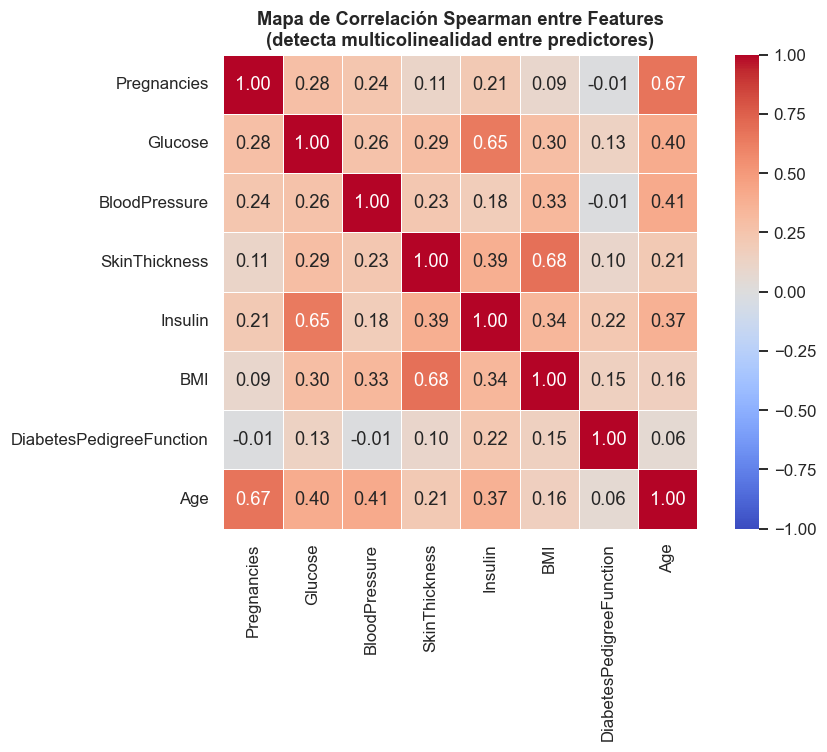

,n0 usado,n1 usado,U statistic,p-valor,Significativa?,r (efecto),Tamaño efecto
Variable,,,,,,,
Glucose,1506,936,250571.000000,0.000000,SÍ,0.644500,Grande
Insulin,773,438,82993.000000,0.000000,SÍ,0.509700,Grande
Age,1519,941,409831.000000,0.000000,SÍ,0.426600,Grande
BMI,1495,936,402082.500000,0.000000,SÍ,0.425300,Grande
SkinThickness,1094,616,204088.500000,0.000000,SÍ,0.394300,Grande
Pregnancies,1519,941,468309.500000,0.000000,SÍ,0.344700,Grande
DiabetesPedigreeFunction,1519,941,527985.500000,0.000000,SÍ,0.261200,Moderado
BloodPressure,1478,902,506427.500000,0.000000,SÍ,0.240300,Moderado


Imagen guardada: Image\05_mann_whitney_efectos.png


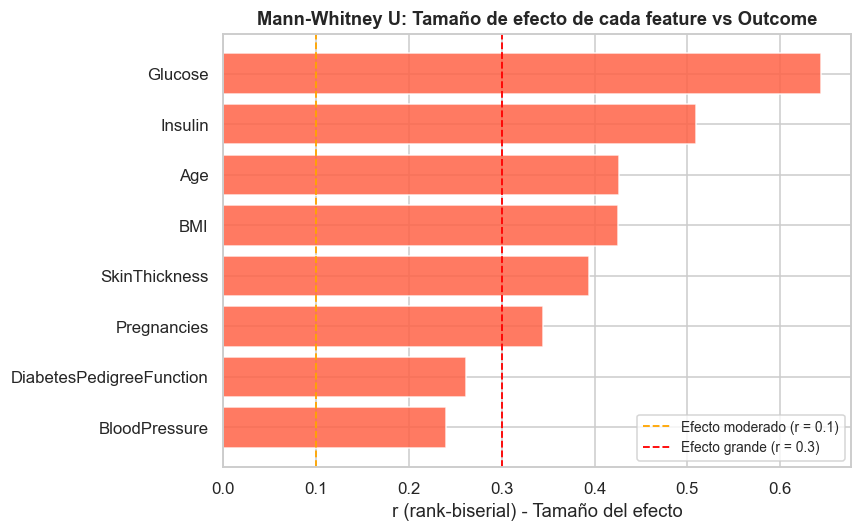

In [10]:
corr_spearman = df_stats[features].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Mapa de Correlación Spearman entre Features\n(detecta multicolinealidad entre predictores)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
guardar_figura('04_heatmap_spearman')
plt.show()

resultados_mw = []
for col in features:
    grupo0 = df_stats.loc[df_stats['Outcome'] == 0, col].dropna()
    grupo1 = df_stats.loc[df_stats['Outcome'] == 1, col].dropna()
    stat, p = mannwhitneyu(grupo0, grupo1, alternative='two-sided')
    n0, n1  = len(grupo0), len(grupo1)
    r       = abs(1 - (2 * stat) / (n0 * n1))
    efecto  = 'Grande' if r >= 0.3 else ('Moderado' if r >= 0.1 else 'Pequeño')
    resultados_mw.append({
        'Variable'      : col,
        'n0 usado'      : n0,
        'n1 usado'      : n1,
        'U statistic'   : round(stat, 2),
        'p-valor'       : round(p, 5),
        'Significativa?': 'SÍ' if p < ALPHA else 'No',
        'r (efecto)'    : round(r, 4),
        'Tamaño efecto' : efecto
    })

df_mw = pd.DataFrame(resultados_mw).set_index('Variable').sort_values('r (efecto)', ascending=False)

display(df_mw.style.map(
    lambda v: 'color:green;font-weight:bold' if v == 'SÍ'
    else ('color:red;font-weight:bold' if v == 'No' else ''),
    subset=['Significativa?']
))

df_plot  = df_mw.sort_values('r (efecto)')
colores  = ['tomato' if v == 'SÍ' else 'lightgray' for v in df_plot['Significativa?']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_plot.index, df_plot['r (efecto)'], color=colores, alpha=0.85)
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1.2, label='Efecto moderado (r = 0.1)')
ax.axvline(0.3, color='red', linestyle='--', linewidth=1.2, label='Efecto grande (r = 0.3)')
ax.set_xlabel('r (rank-biserial) - Tamaño del efecto')
ax.set_title('Mann-Whitney U: Tamaño de efecto de cada feature vs Outcome',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
guardar_figura('05_mann_whitney_efectos', fig)
plt.show()


---
## BLOQUE 2 — Identificación y Tratamiento de Valores Faltantes
### Paso 6 · Identificar tipo de dato faltante y tratar
Las columnas `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI` contienen **ceros biológicamente imposibles** → se tratan como NaN y se imputan con la **mediana global del train**.

> **Criterio idéntico para train y test** (sin usar `Outcome`). Imputar el train por mediana de *clase* introduciría un patrón que el test no tiene en producción: la clase del paciente es justamente lo que se quiere predecir. Eso infla la validación cruzada y arruina la generalización.

| % Faltantes | Impacto | Acción sugerida |
|---|---|---|
| < 1% | Trivial | Imputar (media/mediana) |
| 1% – 5% | Manejable | Imputar (media/mediana) |
| 5% – 15% | Requiere métodos más cuidadosos | Mediana / KNN |
| > 15% | Interpretación perjudicial | Analizar causa raíz + imputar mediana |

In [11]:
cols_chk = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

nan_reales = df_train[cols_chk].isna().sum()
ceros_encubiertos = (df_train[cols_chk] == 0).sum()
faltantes_totales = nan_reales + ceros_encubiertos

print('NaN reales por columna:')
display(nan_reales.to_frame('NaN reales'))
print('Ceros imposibles todavía presentes:', int(ceros_encubiertos.sum()))

reporte_faltantes = pd.DataFrame({
    'NaN reales': nan_reales,
    'Ceros (=faltantes)': ceros_encubiertos,
    'Total faltantes': faltantes_totales,
    '% Faltante': (faltantes_totales / len(df_train) * 100).round(2)
})

print('Faltantes en variables con ceros biológicamente imposibles:')
reporte_faltantes


NaN reales por columna:


,NaN reales
Glucose,18
BloodPressure,80
SkinThickness,750
Insulin,1249
BMI,29


Ceros imposibles todavía presentes: 0
Faltantes en variables con ceros biológicamente imposibles:


,NaN reales,Ceros (=faltantes),Total faltantes,% Faltante
Glucose,18,0,18,0.7300
BloodPressure,80,0,80,3.2500
SkinThickness,750,0,750,30.4900
Insulin,1249,0,1249,50.7700
BMI,29,0,29,1.1800


In [12]:
cols_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Reporte de faltantes: suma NaN reales + ceros imposibles si aún existen.
reporte = []
for col in cols_ceros:
    n_nan = df_train[col].isna().sum()
    n_ceros = (df_train[col] == 0).sum()
    n = n_nan + n_ceros
    pct = n / len(df_train) * 100
    if pct < 5:
        accion = 'Imputar por mediana global (trivial)'
    elif pct <= 15:
        accion = 'Imputar por mediana global (moderado)'
    else:
        accion = 'Crítico: imputar por mediana global + documentar'
    reporte.append({
        'Variable': col,
        'NaN': int(n_nan),
        'Ceros': int(n_ceros),
        'Total faltantes': int(n),
        '% Faltante': round(pct, 2),
        'Acción': accion
    })

pd.DataFrame(reporte).set_index('Variable')


,NaN,Ceros,Total faltantes,% Faltante,Acción
Variable,,,,,
Glucose,18,0,18,0.7300,Imputar por mediana global (trivial)
BloodPressure,80,0,80,3.2500,Imputar por mediana global (trivial)
SkinThickness,750,0,750,30.4900,Crítico: imputar por mediana global + documentar
Insulin,1249,0,1249,50.7700,Crítico: imputar por mediana global + documentar
BMI,29,0,29,1.1800,Imputar por mediana global (trivial)


In [13]:
def reemplazar_ceros_por_nan(df, columnas):
    df = df.copy()
    df[columnas] = df[columnas].replace(0, np.nan)
    return df

def calcular_medianas(df_ref, columnas):
    """Mediana global de cada columna calculada SOLO en el train (ignora NaN)."""
    return {col: float(df_ref[col].median()) for col in columnas}

def imputar_con_medianas(df_in, medianas):
    """Imputa los NaN con las medianas del train.
    Mismo criterio EXACTO para train y test: no usa Outcome, de modo que ambos
    conjuntos reciben el mismo tratamiento y sus distribuciones son comparables.
    (Imputar el train por mediana de CLASE crearía un patrón que el test nunca
    tendría → la validación cruzada se infla y el modelo no generaliza.)"""
    df = df_in.copy()
    for col, med in medianas.items():
        df[col] = df[col].fillna(med)
    return df

df_train_c = reemplazar_ceros_por_nan(df_train, cols_ceros)
df_test_c  = reemplazar_ceros_por_nan(df_test,  cols_ceros)

# Medianas calculadas SOLO en train (evita data leakage) y aplicadas igual a ambos
medianas_imput = calcular_medianas(df_train_c, cols_ceros)
df_train_c = imputar_con_medianas(df_train_c, medianas_imput)
df_test_c  = imputar_con_medianas(df_test_c,  medianas_imput)

print('Medianas de imputación (train):', {k: round(v, 1) for k, v in medianas_imput.items()})
print('Nulos restantes — Train:', df_train_c.isnull().sum().sum())
print('Nulos restantes — Test :', df_test_c.isnull().sum().sum())

Medianas de imputación (train): {'Glucose': 118.0, 'BloodPressure': 72.0, 'SkinThickness': 29.0, 'Insulin': 121.0, 'BMI': 32.4}
Nulos restantes — Train: 0
Nulos restantes — Test : 0


---
## BLOQUE 3 — Identificación y Tratamiento de Outliers
### Paso 7 · Detectar outliers univariados
Flujo: **Shapiro-Wilk** → si normal: regla **k=2 o k=3** → si NO normal: regla **Q1−3×IQR / Q3+3×IQR**

Imagen guardada: Image\06_boxplots_outliers.png


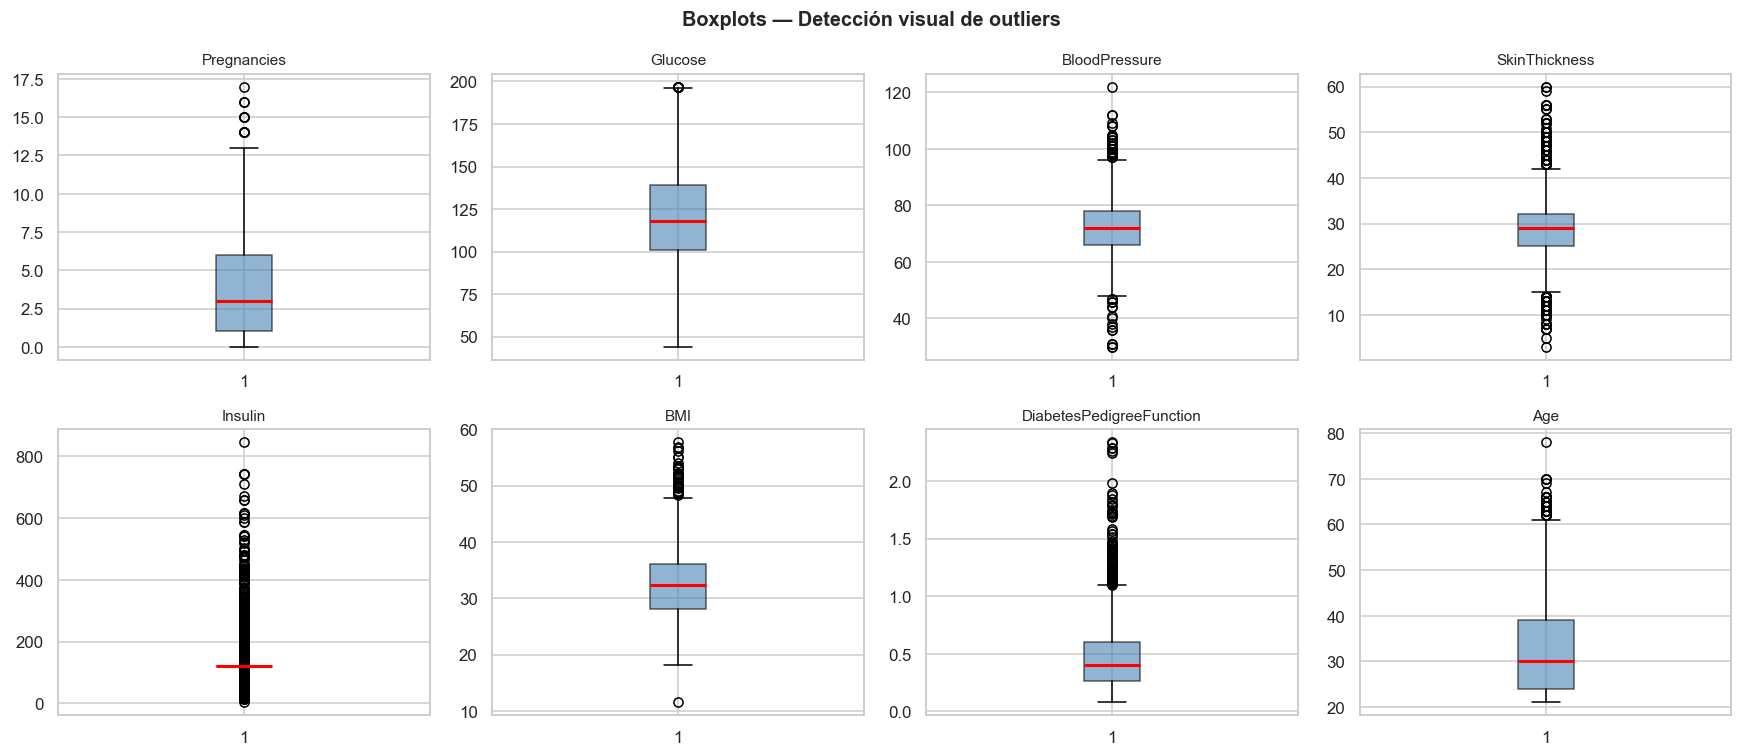

In [14]:
# Boxplots para detección visual
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), features):
    ax.boxplot(df_train_c[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=10)
plt.suptitle('Boxplots — Detección visual de outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
guardar_figura('06_boxplots_outliers', fig)
plt.show()

In [15]:
# Conteo de outliers según criterio de la guía
reporte_out = []
for col in features:
    serie = df_train_c[col]
    _, p_sw = shapiro(serie.sample(min(2000, len(serie)), random_state=42))
    es_normal = p_sw > ALPHA

    if es_normal:
        mu, s = serie.mean(), serie.std()
        k = 3
        mask = (np.abs(serie - mu) / s) > k
        criterio = f'Normal → |z| > {k}'
    else:
        Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
        IQR = Q3 - Q1
        mask = (serie < Q1 - 3*IQR) | (serie > Q3 + 3*IQR)
        criterio = 'NO Normal → IQR×3'

    reporte_out.append({
        'Variable' : col,
        'Normal?'  : 'SÍ' if es_normal else 'NO',
        'Criterio' : criterio,
        'Outliers' : mask.sum(),
        '% del total': round(mask.sum()/len(serie)*100, 2)
    })

df_out = pd.DataFrame(reporte_out).set_index('Variable')
df_out

,Normal?,Criterio,Outliers,% del total
Variable,,,,
Pregnancies,NO,NO Normal → IQR×3,0,0.0000
Glucose,NO,NO Normal → IQR×3,0,0.0000
BloodPressure,NO,NO Normal → IQR×3,1,0.0400
SkinThickness,NO,NO Normal → IQR×3,10,0.4100
Insulin,NO,NO Normal → IQR×3,1205,48.9800
BMI,NO,NO Normal → IQR×3,0,0.0000
DiabetesPedigreeFunction,NO,NO Normal → IQR×3,21,0.8500
Age,NO,NO Normal → IQR×3,0,0.0000


### Paso 8 · Outliers multivariados — Distancia de Mahalanobis
Detecta outliers considerando la interacción entre múltiples variables a la vez.

Umbral Mahalanobis (chi² 97.5%): 4.187
Outliers multivariados detectados: 167 (6.79%)
Imagen guardada: Image\07_mahalanobis_distancias.png


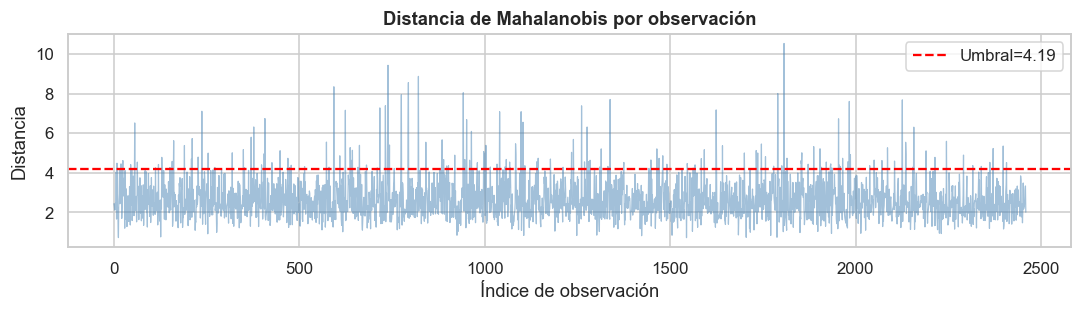

In [16]:
X_mah = df_train_c[features].values
media_vec = np.mean(X_mah, axis=0)
cov_matrix = np.cov(X_mah, rowvar=False)
inv_cov = np.linalg.inv(cov_matrix)

dist_mah = np.array([mahalanobis(x, media_vec, inv_cov) for x in X_mah])

# Umbral: chi² con k grados de libertad al 97.5%
umbral_mah = np.sqrt(stats.chi2.ppf(0.975, df=len(features)))
outliers_mah = (dist_mah > umbral_mah).sum()

print(f'Umbral Mahalanobis (chi² 97.5%): {umbral_mah:.3f}')
print(f'Outliers multivariados detectados: {outliers_mah} ({outliers_mah/len(df_train_c)*100:.2f}%)')

plt.figure(figsize=(10, 3))
plt.plot(dist_mah, alpha=0.5, linewidth=0.8, color='steelblue')
plt.axhline(umbral_mah, color='red', linestyle='--', label=f'Umbral={umbral_mah:.2f}')
plt.title('Distancia de Mahalanobis por observación', fontsize=12, fontweight='bold')
plt.xlabel('Índice de observación')
plt.ylabel('Distancia')
plt.legend()
plt.tight_layout()
guardar_figura('07_mahalanobis_distancias')
plt.show()

### Paso 9 · Tratar outliers
Los outliers univariados detectados son **valores reales** (no errores de captura) y representan un porcentaje bajo por variable. Se aplica **Winsorizing (capping)** con límites IQR×3 **calculados solo en train** y aplicados a train y test con esos mismos límites — así el test no filtra información (data leakage).

Los outliers multivariados de Mahalanobis (~7%) se documentan pero no se eliminan: el capping univariado ya acota sus valores extremos.

> **Regla clave:** nunca eliminar un outlier sin verificar que sea un error real.

In [17]:
def winsorizing_iqr_fit(df_ref, columnas, factor=3.0):
    """Calcula límites IQR×factor sobre el TRAIN (evita data leakage)."""
    limites = {}
    for col in columnas:
        Q1, Q3 = df_ref[col].quantile(0.25), df_ref[col].quantile(0.75)
        IQR = Q3 - Q1
        limites[col] = (Q1 - factor*IQR, Q3 + factor*IQR)
    return limites

def winsorizing_iqr_apply(df, limites):
    """Recorta valores extremos a los límites calculados en train."""
    df = df.copy()
    for col, (lo, hi) in limites.items():
        df[col] = df[col].clip(lower=lo, upper=hi)
    return df

limites_iqr = winsorizing_iqr_fit(df_train_c, features)
df_train_c  = winsorizing_iqr_apply(df_train_c, limites_iqr)
df_test_c   = winsorizing_iqr_apply(df_test_c,  limites_iqr)   # límites del TRAIN

print('Winsorizing IQR×3 aplicado (límites del train). Verificación rápida de rangos:')
df_train_c[features].agg(['min','max']).T

Winsorizing IQR×3 aplicado (límites del train). Verificación rápida de rangos:


,min,max
Pregnancies,0.0000,17.0000
Glucose,44.0000,197.0000
BloodPressure,30.0000,114.0000
SkinThickness,4.0000,53.0000
Insulin,121.0000,121.0000
BMI,11.5000,57.7000
DiabetesPedigreeFunction,0.0780,1.6010
Age,21.0000,78.0000


---
## BLOQUE 4 — Transformación y Escalado
### Paso 10 · Transformar distribuciones sesgadas
Si **Asimetría > 1** (sesgo positivo fuerte) → aplicar `log1p` para reducir la cola derecha.

In [18]:
# Columnas con sesgo positivo significativo (As > 1)
asimetria = df_train_c[features].skew()
cols_sesgadas = asimetria[asimetria > 1].index.tolist()
print('Variables con sesgo positivo > 1:', cols_sesgadas)
print(asimetria.sort_values(ascending=False).to_string())

Variables con sesgo positivo > 1: ['DiabetesPedigreeFunction', 'Age']
DiabetesPedigreeFunction   1.5304
Age                        1.1595
Pregnancies                0.9278
Glucose                    0.5223
BMI                        0.4906
SkinThickness              0.0729
BloodPressure              0.0502
Insulin                    0.0000


In [19]:
# Aplicar log1p a variables con As > 1
df_train_t = df_train_c.copy()
df_test_t  = df_test_c.copy()

for col in cols_sesgadas:
    df_train_t[col] = np.log1p(df_train_t[col])
    df_test_t[col]  = np.log1p(df_test_t[col])

# Comparar asimetría antes y después
comparacion = pd.DataFrame({
    'As. antes': df_train_c[features].skew().round(3),
    'As. después': df_train_t[features].skew().round(3)
})
comparacion['Mejoró?'] = comparacion.apply(
    lambda r: 'SÍ ✔' if abs(r['As. después']) < abs(r['As. antes']) else '—', axis=1)
comparacion

,As. antes,As. después,Mejoró?
Pregnancies,0.9280,0.9280,—
Glucose,0.5220,0.5220,—
BloodPressure,0.0500,0.0500,—
SkinThickness,0.0730,0.0730,—
Insulin,0.0000,0.0000,—
BMI,0.4910,0.4910,—
DiabetesPedigreeFunction,1.5300,0.9990,SÍ ✔
Age,1.1590,0.6250,SÍ ✔


### Paso 11 · Escalar variables numéricas
Como existen outliers → se usa **RobustScaler** (usa mediana e IQR, inmune a valores extremos).

> **Regla de oro:** Si dudas qué escalador usar → usa RobustScaler.

In [20]:
X_train = df_train_t[features]
y_train = df_train_t['Outcome']
X_test  = df_test_t[features]
y_test  = df_test_t['Outcome']

scaler = RobustScaler()                     # RobustScaler → hay outliers (guía paso 11)
X_train_sc = scaler.fit_transform(X_train)  # fit solo en train
X_test_sc  = scaler.transform(X_test)       # transform en test

X_train_sc = pd.DataFrame(X_train_sc, columns=features)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=features)

print('Escalado completado. Media post-escalado (≈0):')
print(X_train_sc.mean().round(3).to_string())

Escalado completado. Media post-escalado (≈0):
Pregnancies                 0.1620
Glucose                     0.1080
BloodPressure               0.0300
SkinThickness              -0.0600
Insulin                     0.0000
BMI                         0.0140
DiabetesPedigreeFunction    0.1460
Age                         0.0890


---
## BLOQUE 5 — Discretización
### Paso 12 · Discretizar variables de interés clínico
Con outliers → **Equal Frequency (pd.qcut)** — se adapta a la distribución real.

In [21]:
disc = df_train_c.copy()  # usar datos sin escalar para interpretabilidad

disc['Glucose.cat'] = pd.qcut(
    disc['Glucose'], q=3,
    labels=['Baja', 'Normal', 'Alta']
)
disc['BMI.cat'] = pd.qcut(
    disc['BMI'], q=3,
    labels=['Bajo', 'Normal', 'Alto']
)
disc['Age.cat'] = pd.qcut(
    disc['Age'], q=3,
    labels=['Joven', 'Adulto', 'Mayor']
)

print('Variables discretizadas:')
display(disc[['Glucose','Glucose.cat','BMI','BMI.cat','Age','Age.cat']].head(8))

Variables discretizadas:


,Glucose,Glucose.cat,BMI,BMI.cat,Age,Age.cat
0,151.0000,Alta,34.5000,Normal,27,Adulto
1,91.0000,Baja,22.5000,Bajo,22,Joven
2,139.0000,Alta,40.1000,Alto,35,Adulto
3,118.0000,Normal,33.3000,Normal,23,Joven
4,132.0000,Alta,24.6000,Bajo,23,Joven
5,106.0000,Baja,36.0000,Alto,24,Joven
6,181.0000,Alta,40.0000,Alto,22,Joven
7,107.0000,Baja,38.4000,Alto,36,Mayor


Imagen guardada: Image\08_tasa_diabetes_glucosa.png


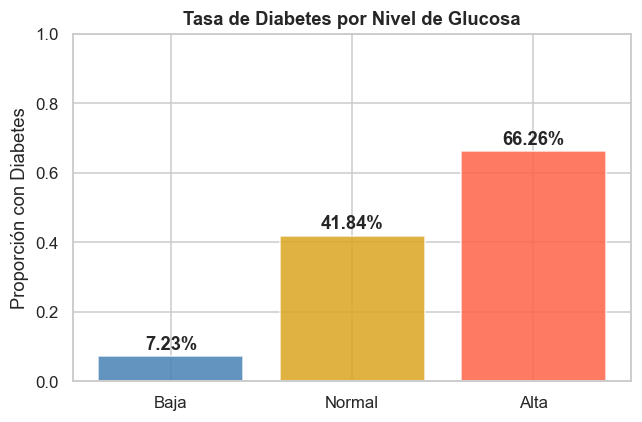

In [22]:
# Tasa de diabetes por categoría de glucosa
tasa = disc.groupby('Glucose.cat')['Outcome'].mean().reset_index()
tasa.columns = ['Glucosa', 'Tasa de Diabetes']

plt.figure(figsize=(6, 4))
plt.bar(tasa['Glucosa'].astype(str), tasa['Tasa de Diabetes'],
        color=['steelblue','goldenrod','tomato'], alpha=0.85)
plt.title('Tasa de Diabetes por Nivel de Glucosa', fontsize=12, fontweight='bold')
plt.ylabel('Proporción con Diabetes')
plt.ylim(0, 1)
for i, v in enumerate(tasa['Tasa de Diabetes']):
    plt.text(i, v+0.02, f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
guardar_figura('08_tasa_diabetes_glucosa')
plt.show()

---
## Verificación — Dataset listo para modelado

---
## BLOQUE 6 — Modelado Predictivo
### Paso 13 · Búsqueda del mejor K para KNN (CV 10-fold en train)
El K se elige con **StratifiedKFold de 10 folds sobre el train**. El test queda reservado exclusivamente para la evaluación final.

In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import cohen_kappa_score
import time

def buscar_mejor_k(X_train, y_train, k_max=25):
    """Busca el mejor K para KNN con validación cruzada 10-fold sobre el train.
    El test no participa: usarlo para elegir K sesgaría la evaluación final."""
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    resultados = []
    for k in range(1, k_max + 1):
        knn = KNeighborsClassifier(n_neighbors=k)
        auc = cross_val_score(knn, X_train, y_train, cv=cv, scoring='roc_auc').mean()
        resultados.append({'K_Vecinos': k, 'ROC_AUC_CV': auc})

    df_resultados = pd.DataFrame(resultados)

    plt.figure(figsize=(10, 5))
    plt.plot(df_resultados['K_Vecinos'], df_resultados['ROC_AUC_CV'],
             marker='o', linestyle='--', color='teal')
    plt.title('Número de Vecinos (K) vs. ROC AUC (CV 10-fold en train)', fontsize=12, fontweight='bold')
    plt.xlabel('Número de Vecinos (K)')
    plt.ylabel('ROC AUC (validación cruzada)')
    plt.xticks(range(1, k_max + 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    guardar_figura('09_knn_k_vs_auc')
    plt.show()

    return df_resultados

Imagen guardada: Image\09_knn_k_vs_auc.png


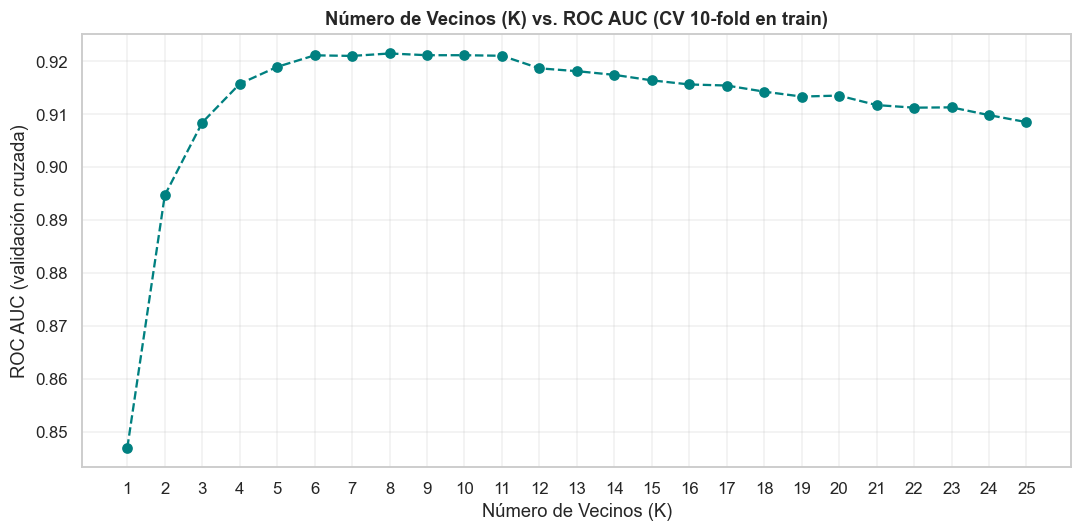

,K_Vecinos,ROC_AUC_CV
7,8,0.9215
9,10,0.9211
8,9,0.9211
5,6,0.9211
10,11,0.9210
6,7,0.9210
4,5,0.9189
11,12,0.9187
12,13,0.9181
13,14,0.9174


In [24]:
resultados_knn = buscar_mejor_k(X_train_sc, y_train, k_max=25)
display(resultados_knn.sort_values(by='ROC_AUC_CV', ascending=False).head(10))

### Paso 14 · Entrenamiento y Métricas de todos los modelos (GridSearchCV 10-fold)
Se tunean **5 modelos base**: KNN, Naive Bayes, SVM (RBF), **Regresión Logística** y Red Neuronal MLP.

Cada modelo pasa por **GridSearchCV** con validación cruzada 10-fold estratificada sobre el train (scoring `roc_auc`). El test se usa **solo** para la evaluación final.

**Métricas reportadas:** Accuracy, Precision, Recall, F1, **Kappa de Cohen** (concordancia corregida por azar) y **Gini** (= 2·AUC − 1).

In [25]:
def mejorModelo(X_train, X_test, y_train, y_test, k_optimo):
    """Tunea con GridSearchCV (CV 10-fold estratificada en train, scoring roc_auc)
    y compara los 5 modelos base. El test solo se usa en la evaluación final."""

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    modelos_grids = {
        'KNN': (
            KNeighborsClassifier(),
            {'n_neighbors': sorted(set(list(range(3, 32, 2)) + [int(k_optimo)])),
             'weights'    : ['uniform', 'distance'],
             'metric'     : ['euclidean', 'manhattan']}
        ),
        'Naive Bayes': (
            GaussianNB(),
            {'var_smoothing': np.logspace(-12, -6, 13)}
        ),
        'SVM': (
            SVC(kernel='rbf', probability=True, random_state=42),
            {'C'    : [0.1, 0.5, 1, 5, 10, 50],
             'gamma': ['scale', 0.005, 0.01, 0.05, 0.1, 0.5]}
        ),
        'Regresión Logística': (
            LogisticRegression(max_iter=2000, random_state=42, solver='liblinear'),
            {'C'           : np.logspace(-3, 2, 12),
             'penalty'     : ['l1', 'l2'],
             'class_weight': [None, 'balanced']}
        ),
        'MLP (Red Neuronal)': (
            MLPClassifier(max_iter=500, random_state=42,
                          early_stopping=True, validation_fraction=0.1),
            {'hidden_layer_sizes': [(32,), (64, 32), (128, 64)],
             'alpha'             : [1e-4, 1e-3, 1e-2],
             'learning_rate_init': [1e-3, 1e-2]}
        )
    }

    resultados = []
    modelos_entrenados = {}

    for nombre, (base, grid) in modelos_grids.items():
        n_comb = int(np.prod([len(v) for v in grid.values()]))
        print(f'🔍 {nombre}: GridSearchCV — {n_comb} combinaciones × 10 folds = {n_comb*10} entrenamientos ...')
        t0 = time.time()
        gs = GridSearchCV(base, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
        gs.fit(X_train, y_train)
        modelo = gs.best_estimator_
        t1 = time.time()

        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

        acc   = accuracy_score(y_test, y_pred)
        prec  = precision_score(y_test, y_pred, zero_division=0)
        rec   = recall_score(y_test, y_pred, zero_division=0)
        f1    = f1_score(y_test, y_pred, zero_division=0)
        kappa = cohen_kappa_score(y_test, y_pred)
        auc   = roc_auc_score(y_test, y_proba)
        gini  = 2*auc - 1

        resultados.append({
            'Modelo'   : nombre,
            'Accuracy' : round(acc, 4),
            'Precision': round(prec, 4),
            'Recall'   : round(rec, 4),
            'F1-Score' : round(f1, 4),
            'Kappa'    : round(kappa, 4),
            'ROC AUC'  : round(auc, 4),
            'Gini'     : round(gini, 4)
        })
        modelos_entrenados[nombre] = modelo
        print(f'   ⏱ {t1-t0:.1f}s · AUC CV (train, 10-fold) = {gs.best_score_:.4f}')
        print(f'   Mejores parámetros: {gs.best_params_}')
        print(f'   {nombre:22s} ACC={acc:.4f}  F1={f1:.4f}  KAPPA={kappa:.4f}  AUC={auc:.4f}  GINI={gini:.4f}\n')

    df_res = pd.DataFrame(resultados).set_index('Modelo')
    mejor  = df_res['ROC AUC'].idxmax()
    print(f'=> Modelo con mejor ROC AUC en test: {mejor} ({df_res.loc[mejor, "ROC AUC"]:.4f})')

    return modelos_entrenados, df_res

best_k = resultados_knn.loc[resultados_knn['ROC_AUC_CV'].idxmax(), 'K_Vecinos']
modelos_dict, tabla_metricas = mejorModelo(X_train_sc, X_test_sc, y_train, y_test, int(best_k))
display(tabla_metricas.style.highlight_max(color='lightgreen', axis=0))

🔍 KNN: GridSearchCV — 64 combinaciones × 10 folds = 640 entrenamientos ...
   ⏱ 5.9s · AUC CV (train, 10-fold) = 0.9377
   Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'}
   KNN                    ACC=0.7792  F1=0.6458  KAPPA=0.4857  AUC=0.8370  GINI=0.6739

🔍 Naive Bayes: GridSearchCV — 13 combinaciones × 10 folds = 130 entrenamientos ...
   ⏱ 0.4s · AUC CV (train, 10-fold) = 0.8536
   Mejores parámetros: {'var_smoothing': np.float64(1e-12)}
   Naive Bayes            ACC=0.7695  F1=0.6635  KAPPA=0.4919  AUC=0.8566  GINI=0.7131

🔍 SVM: GridSearchCV — 36 combinaciones × 10 folds = 360 entrenamientos ...
   ⏱ 60.7s · AUC CV (train, 10-fold) = 0.9345
   Mejores parámetros: {'C': 5, 'gamma': 0.5}
   SVM                    ACC=0.7565  F1=0.6073  KAPPA=0.4310  AUC=0.8073  GINI=0.6146

🔍 Regresión Logística: GridSearchCV — 48 combinaciones × 10 folds = 480 entrenamientos ...
   ⏱ 1.2s · AUC CV (train, 10-fold) = 0.8665
   Mejores parámetros: {'C': np.float

,Accuracy,Precision,Recall,F1-Score,Kappa,ROC AUC,Gini
Modelo,,,,,,,
KNN,0.779200,0.626300,0.666700,0.645800,0.485700,0.837000,0.673900
Naive Bayes,0.769500,0.593200,0.752700,0.663500,0.491900,0.856600,0.713100
SVM,0.756500,0.591800,0.623700,0.607300,0.431000,0.807300,0.614600
Regresión Logística,0.811700,0.692300,0.677400,0.684800,0.550500,0.873900,0.747800
MLP (Red Neuronal),0.772700,0.621100,0.634400,0.627700,0.464100,0.828100,0.656200


### Paso 15 · Matrices de Confusión y Curvas ROC

Imagen guardada: Image\10_matrices_confusion_modelos_base.png


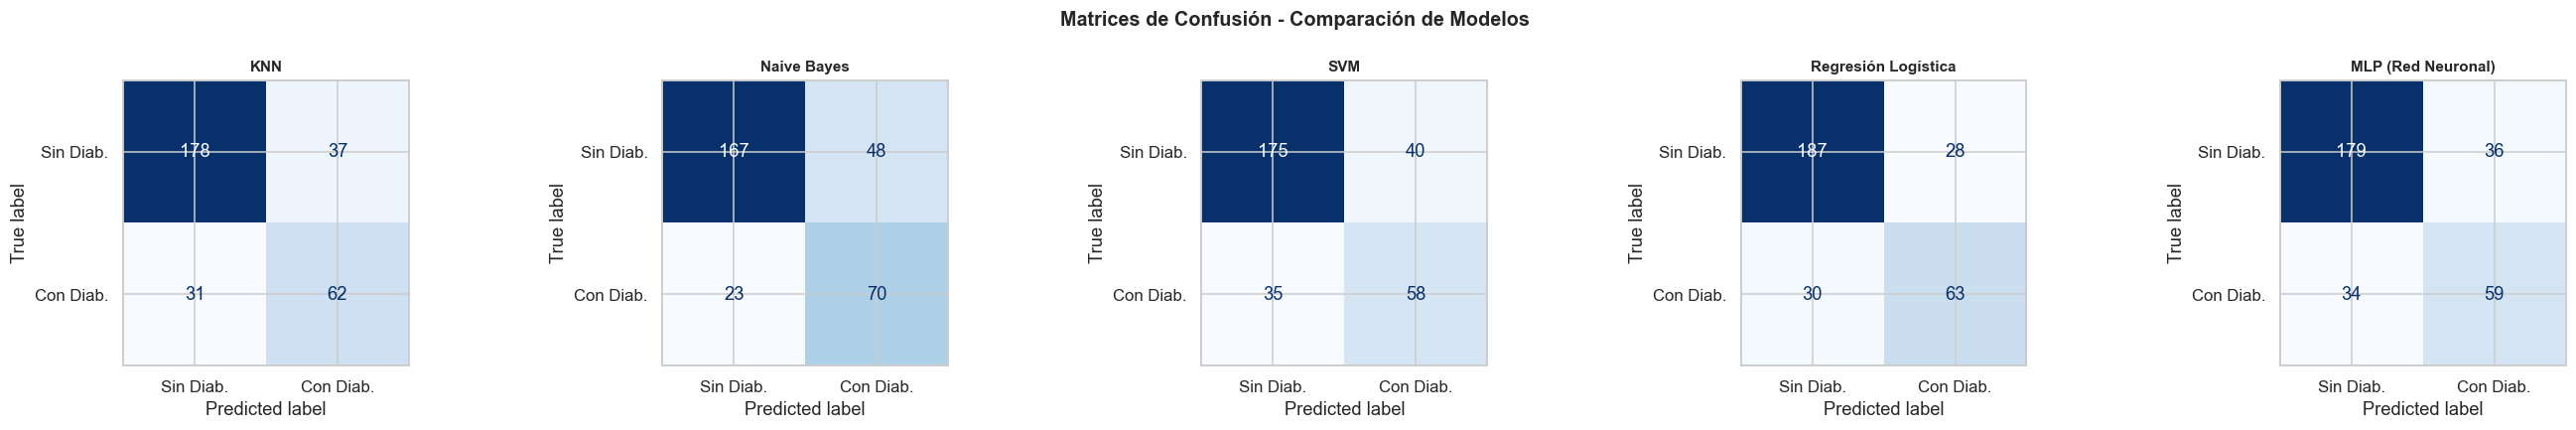

Imagen guardada: Image\11_roc_modelos_base.png


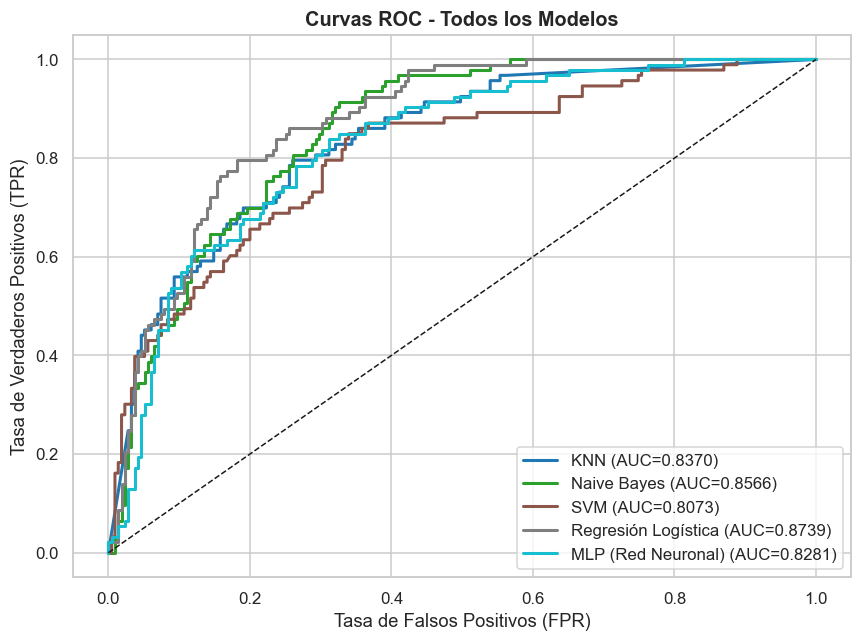

In [26]:
n_mod = len(modelos_dict)
fig, axes = plt.subplots(1, n_mod, figsize=(5*n_mod, 4))

for ax, (nombre, modelo) in zip(axes, modelos_dict.items()):
    y_pred = modelo.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Sin Diab.','Con Diab.']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(nombre, fontsize=10, fontweight='bold')

plt.suptitle('Matrices de Confusión - Comparación de Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
guardar_figura('10_matrices_confusion_modelos_base', fig)
plt.show()

plt.figure(figsize=(8, 6))
colores = plt.cm.tab10(np.linspace(0, 1, n_mod))

for (nombre, modelo), color in zip(modelos_dict.items(), colores):
    y_proba = modelo.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.4f})', color=color, linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Todos los Modelos', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
guardar_figura('11_roc_modelos_base')
plt.show()


### Paso 16 · Análisis de Lift por Decil
El **Lift** mide cuánto mejor es el modelo que seleccionar al azar.  
Un Lift de 2.0 en el primer decil significa que al contactar al 10% de mayor score, se captura **2× más positivos** que seleccionando aleatoriamente.

In [27]:
# ── Curvas de Lift y tablas de deciles para todos los modelos ────────────────

def calcular_lift_deciles(nombre, modelo, X_test, y_test):
    """Calcula tabla de lift por decil para un modelo dado."""
    probs = modelo.predict_proba(X_test)[:, 1]
    df_res = pd.DataFrame({'Target': np.array(y_test), 'Prob': probs})
    df_res['Decil'] = pd.qcut(df_res['Prob'].rank(method='first'), 10, labels=range(1, 11))

    tasa_media_global = df_res['Target'].mean()
    res = df_res.groupby('Decil').agg(
        Total_Casos=('Target', 'count'),
        Casos_Positivos=('Target', 'sum')
    ).reset_index()
    res['Tasa_Exito'] = res['Casos_Positivos'] / res['Total_Casos']
    res['Lift']       = res['Tasa_Exito'] / tasa_media_global
    res['Modelo']     = nombre
    return res.sort_values('Decil', ascending=False), tasa_media_global

# Mostrar tablas de deciles por modelo
for nombre, modelo in modelos_dict.items():
    tabla, _ = calcular_lift_deciles(nombre, modelo, X_test_sc, y_test)
    print(f"\n{'='*60}")
    print(f"  Tabla de Lift por Decil — {nombre}")
    print(f"{'='*60}")
    display(tabla[['Decil','Total_Casos','Casos_Positivos','Tasa_Exito','Lift']]
            .style.format({'Tasa_Exito': '{:.2%}', 'Lift': '{:.3f}'})
            .bar(subset=['Lift'], color='#5fba7d'))


  Tabla de Lift por Decil — KNN


,Decil,Total_Casos,Casos_Positivos,Tasa_Exito,Lift
9,10,31,24,77.42%,2.564
8,9,31,22,70.97%,2.350
7,8,31,13,41.94%,1.389
6,7,30,10,33.33%,1.104
5,6,31,10,32.26%,1.068
4,5,31,6,19.35%,0.641
3,4,30,6,20.00%,0.662
2,3,31,1,3.23%,0.107
1,2,31,1,3.23%,0.107
0,1,31,0,0.00%,0.000



  Tabla de Lift por Decil — Naive Bayes


,Decil,Total_Casos,Casos_Positivos,Tasa_Exito,Lift
9,10,31,24,77.42%,2.564
8,9,31,19,61.29%,2.030
7,8,31,17,54.84%,1.816
6,7,30,11,36.67%,1.214
5,6,31,13,41.94%,1.389
4,5,31,6,19.35%,0.641
3,4,30,3,10.00%,0.331
2,3,31,0,0.00%,0.000
1,2,31,0,0.00%,0.000
0,1,31,0,0.00%,0.000



  Tabla de Lift por Decil — SVM


,Decil,Total_Casos,Casos_Positivos,Tasa_Exito,Lift
9,10,31,26,83.87%,2.778
8,9,31,18,58.06%,1.923
7,8,31,12,38.71%,1.282
6,7,30,9,30.00%,0.994
5,6,31,14,45.16%,1.496
4,5,31,3,9.68%,0.320
3,4,30,1,3.33%,0.110
2,3,31,6,19.35%,0.641
1,2,31,2,6.45%,0.214
0,1,31,2,6.45%,0.214



  Tabla de Lift por Decil — Regresión Logística


,Decil,Total_Casos,Casos_Positivos,Tasa_Exito,Lift
9,10,31,24,77.42%,2.564
8,9,31,21,67.74%,2.243
7,8,31,18,58.06%,1.923
6,7,30,12,40.00%,1.325
5,6,31,7,22.58%,0.748
4,5,31,9,29.03%,0.961
3,4,30,1,3.33%,0.110
2,3,31,1,3.23%,0.107
1,2,31,0,0.00%,0.000
0,1,31,0,0.00%,0.000



  Tabla de Lift por Decil — MLP (Red Neuronal)


,Decil,Total_Casos,Casos_Positivos,Tasa_Exito,Lift
9,10,31,21,67.74%,2.243
8,9,31,23,74.19%,2.457
7,8,31,14,45.16%,1.496
6,7,30,11,36.67%,1.214
5,6,31,10,32.26%,1.068
4,5,31,6,19.35%,0.641
3,4,30,4,13.33%,0.442
2,3,31,2,6.45%,0.214
1,2,31,2,6.45%,0.214
0,1,31,0,0.00%,0.000


Imagen guardada: Image\12_lift_deciles_modelos_base.png


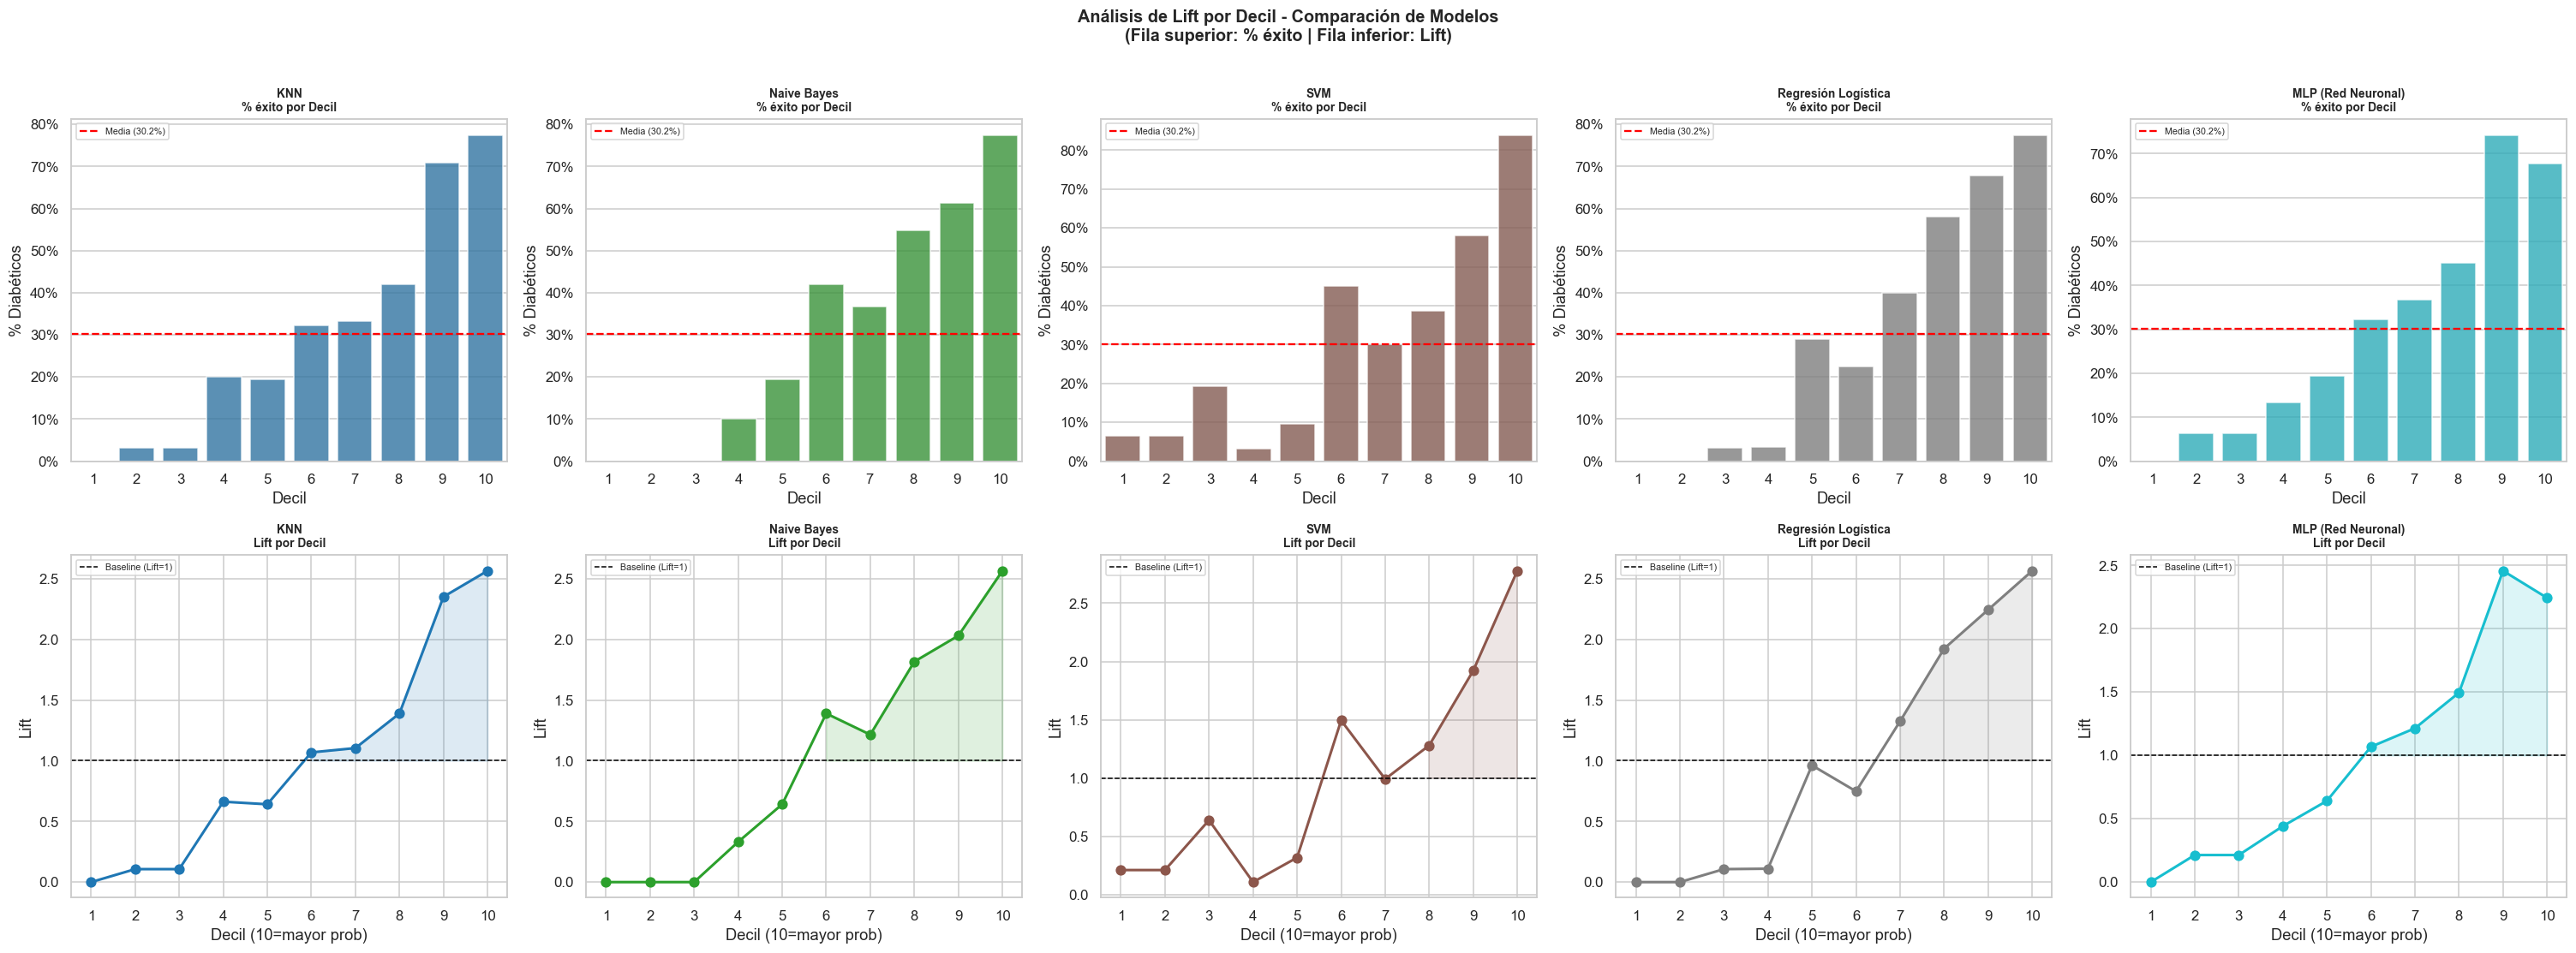

Imagen guardada: Image\13_lift_acumulado_modelos_base.png


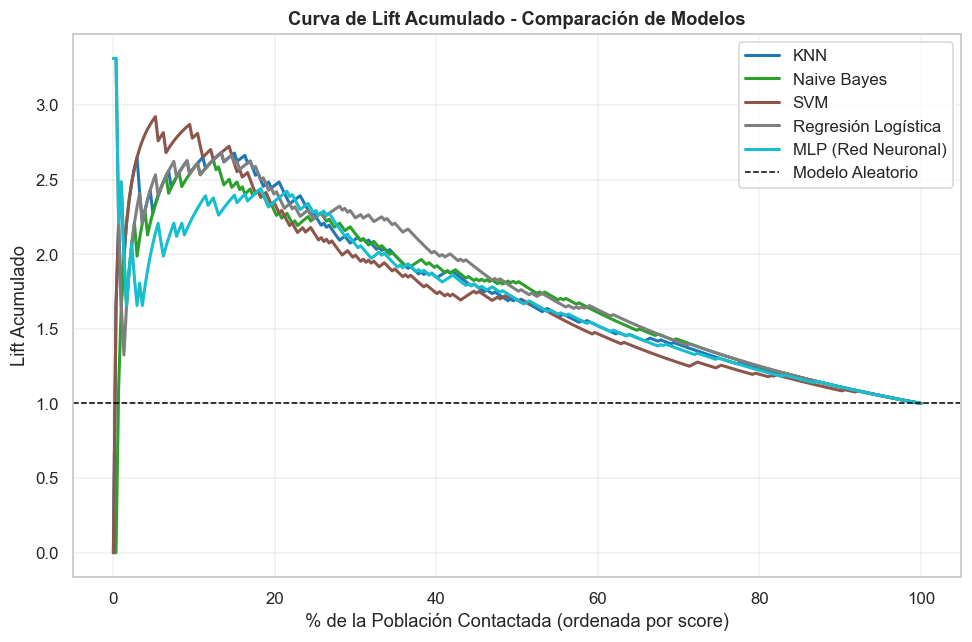

In [28]:
n_mod = len(modelos_dict)
colores_modelos = plt.cm.tab10(np.linspace(0, 1, n_mod))
fig, axes = plt.subplots(2, n_mod, figsize=(5.5*n_mod, 10))

for idx, (nombre, modelo) in enumerate(modelos_dict.items()):
    tabla, tasa_global = calcular_lift_deciles(nombre, modelo, X_test_sc, y_test)
    color = colores_modelos[idx]

    ax_exito = axes[0][idx]
    sns.barplot(x='Decil', y='Tasa_Exito', data=tabla, ax=ax_exito,
                color=color, alpha=0.8)
    ax_exito.axhline(tasa_global, color='red', linestyle='--', linewidth=1.5,
                     label=f'Media ({tasa_global:.1%})')
    ax_exito.set_title(f'{nombre}\n% éxito por Decil', fontsize=9, fontweight='bold')
    ax_exito.set_ylabel('% Diabéticos')
    ax_exito.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax_exito.legend(fontsize=7)

    ax_lift = axes[1][idx]
    tabla_plot = tabla.sort_values('Decil')
    ax_lift.plot(tabla_plot['Decil'].astype(str), tabla_plot['Lift'],
                 marker='o', color=color, linewidth=2, markersize=7)
    ax_lift.axhline(1, color='black', linestyle='--', linewidth=1, label='Baseline (Lift=1)')
    ax_lift.fill_between(range(len(tabla_plot)), tabla_plot['Lift'].values, 1,
                         where=tabla_plot['Lift'].values > 1, alpha=0.15, color=color)
    ax_lift.set_title(f'{nombre}\nLift por Decil', fontsize=9, fontweight='bold')
    ax_lift.set_ylabel('Lift')
    ax_lift.set_xlabel('Decil (10=mayor prob)')
    ax_lift.legend(fontsize=7)

plt.suptitle('Análisis de Lift por Decil - Comparación de Modelos\n(Fila superior: % éxito | Fila inferior: Lift)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
guardar_figura('12_lift_deciles_modelos_base', fig)
plt.show()

plt.figure(figsize=(9, 6))
for (nombre, modelo), color in zip(modelos_dict.items(), colores_modelos):
    probs = modelo.predict_proba(X_test_sc)[:, 1]
    df_res = pd.DataFrame({'Target': np.array(y_test), 'Prob': probs})
    df_res = df_res.sort_values('Prob', ascending=False).reset_index(drop=True)
    tasa_global = df_res['Target'].mean()
    cum_positivos = df_res['Target'].cumsum()
    cum_total = np.arange(1, len(df_res)+1)
    lift_acum = (cum_positivos / cum_total) / tasa_global
    x_pct = np.linspace(0, 100, len(lift_acum))
    plt.plot(x_pct, lift_acum, label=nombre, color=color, linewidth=2)

plt.axhline(1, color='black', linestyle='--', linewidth=1, label='Modelo Aleatorio')
plt.xlabel('% de la Población Contactada (ordenada por score)')
plt.ylabel('Lift Acumulado')
plt.title('Curva de Lift Acumulado - Comparación de Modelos', fontsize=12, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
guardar_figura('13_lift_acumulado_modelos_base')
plt.show()


### Paso 17 · Resumen Ejecutivo — Selección del Mejor Modelo


  RESUMEN EJECUTIVO — COMPARACIÓN DE MODELOS


,Accuracy,Precision,Recall,F1-Score,Kappa,ROC AUC,Gini
Modelo,,,,,,,
KNN,0.7792,0.6263,0.6667,0.6458,0.4857,0.8370,0.6739
Naive Bayes,0.7695,0.5932,0.7527,0.6635,0.4919,0.8566,0.7131
SVM,0.7565,0.5918,0.6237,0.6073,0.4310,0.8073,0.6146
Regresión Logística,0.8117,0.6923,0.6774,0.6848,0.5505,0.8739,0.7478
MLP (Red Neuronal),0.7727,0.6211,0.6344,0.6277,0.4641,0.8281,0.6562


Imagen guardada: Image\15_metricas_modelos_base.png


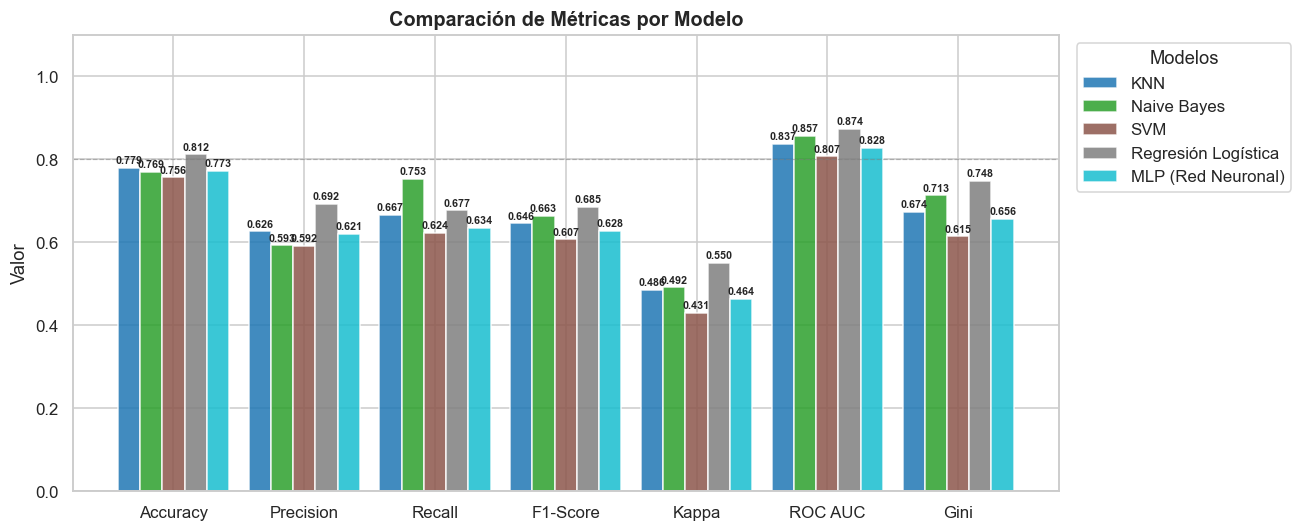


✅ MEJOR MODELO BASE: Regresión Logística
   ROC AUC  : 0.8739
   F1-Score : 0.6848
   Accuracy : 0.8117



In [29]:
# ── Resumen ejecutivo: comparación de métricas ───────────────────────────────

print("\n" + "="*65)
print("  RESUMEN EJECUTIVO — COMPARACIÓN DE MODELOS")
print("="*65)
display(tabla_metricas.style
    .highlight_max(color='lightgreen', axis=0)
    .highlight_min(color='#ffcccc', axis=0)
    .format('{:.4f}')
    .set_caption("Verde = mejor valor | Rojo = peor valor por columna"))

# Gráfica de radar / bar comparativa de métricas
metricas_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Kappa', 'ROC AUC', 'Gini']
df_plot = tabla_metricas[metricas_cols].T

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metricas_cols))
width = 0.85 / len(df_plot.columns)
colors_bar = plt.cm.tab10(np.linspace(0, 1, len(df_plot.columns)))

for i, (col, color) in enumerate(zip(df_plot.columns, colors_bar)):
    offset = (i - len(df_plot.columns)/2 + 0.5) * width
    bars = ax.bar(x + offset, df_plot[col], width, label=col, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metricas_cols)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas por Modelo', fontsize=13, fontweight='bold')
ax.legend(title='Modelos', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
guardar_figura('15_metricas_modelos_base', fig)
plt.show()

mejor_base_nombre = tabla_metricas['ROC AUC'].idxmax()
mejor_base_obj    = modelos_dict[mejor_base_nombre]
print(f"\n✅ MEJOR MODELO BASE: {mejor_base_nombre}")
print(f"   ROC AUC  : {tabla_metricas.loc[mejor_base_nombre,'ROC AUC']:.4f}")
print(f"   F1-Score : {tabla_metricas.loc[mejor_base_nombre,'F1-Score']:.4f}")
print(f"   Accuracy : {tabla_metricas.loc[mejor_base_nombre,'Accuracy']:.4f}")
print("\n" + "="*65)

---
## BLOQUE 7 — Modelos de Ensamble: Bagging y Boosting (GridSearchCV 10-fold)
### Paso 18 · Entrenamiento de modelos de ensamble

Se tunean **5 modelos de ensamble** para comparar con los modelos base:

- **Bagging de Árboles** — promedia varios árboles entrenados con muestras bootstrap (reduce varianza)
- **AdaBoost** — boosting clásico que reentrena enfocándose en los errores previos
- **Gradient Boosting** — boosting que minimiza el residuo por gradiente descendente
- **XGBoost** — implementación optimizada de gradient boosting (regularización L1/L2)
- **LightGBM** — boosting basado en histogramas, muy rápido y eficiente

Cada uno pasa por **GridSearchCV** (CV 10-fold estratificada, scoring `roc_auc`). Todos usan los mismos `X_train_sc`, `X_test_sc`, `y_train`, `y_test` para que la comparación sea justa.

In [30]:
# ── Librerías de ensamble ─────────────────────────────────────────────────────
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# XGBoost y LightGBM (instalar si no están: pip install xgboost lightgbm shap)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


def mejorModeloEnsamble(X_train, X_test, y_train, y_test):
    """Tunea con GridSearchCV (CV 10-fold estratificada, scoring roc_auc)
    y compara los 5 modelos de ensamble."""

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    modelos_grids = {
        'Bagging (Árboles)': (
            BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                              bootstrap=True, random_state=42, n_jobs=-1),
            {'n_estimators': [100, 200, 400],
             'max_samples' : [0.6, 0.8, 1.0],
             'max_features': [0.6, 0.8, 1.0]}
        ),
        'AdaBoost': (
            AdaBoostClassifier(random_state=42),
            {'estimator'    : [DecisionTreeClassifier(max_depth=1, random_state=42),
                               DecisionTreeClassifier(max_depth=2, random_state=42),
                               DecisionTreeClassifier(max_depth=3, random_state=42)],
             'n_estimators' : [100, 200, 400],
             'learning_rate': [0.05, 0.1, 0.5, 1.0]}
        ),
        'Gradient Boosting': (
            GradientBoostingClassifier(random_state=42),
            {'n_estimators' : [100, 200, 400],
             'learning_rate': [0.01, 0.05, 0.1],
             'max_depth'    : [2, 3, 4]}
        ),
        'XGBoost': (
            XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
            {'n_estimators'    : [200, 400],
             'learning_rate'   : [0.01, 0.05, 0.1],
             'max_depth'       : [3, 4, 6],
             'subsample'       : [0.8, 1.0],
             'colsample_bytree': [0.8, 1.0]}
        ),
        'LightGBM': (
            LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
            {'n_estimators'     : [200, 400],
             'learning_rate'    : [0.01, 0.05, 0.1],
             'num_leaves'       : [15, 31, 63],
             'min_child_samples': [10, 20, 40]}
        )
    }

    resultados = []
    modelos_entrenados = {}

    for nombre, (base, grid) in modelos_grids.items():
        n_comb = int(np.prod([len(v) for v in grid.values()]))
        print(f'🔍 {nombre}: GridSearchCV — {n_comb} combinaciones × 10 folds = {n_comb*10} entrenamientos ...')
        t0 = time.time()
        gs = GridSearchCV(base, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
        gs.fit(X_train, y_train)
        modelo = gs.best_estimator_
        t1 = time.time()

        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

        acc   = accuracy_score(y_test, y_pred)
        prec  = precision_score(y_test, y_pred, zero_division=0)
        rec   = recall_score(y_test, y_pred, zero_division=0)
        f1    = f1_score(y_test, y_pred, zero_division=0)
        kappa = cohen_kappa_score(y_test, y_pred)
        auc   = roc_auc_score(y_test, y_proba)
        gini  = 2*auc - 1

        resultados.append({
            'Modelo'   : nombre,
            'Accuracy' : round(acc, 4),
            'Precision': round(prec, 4),
            'Recall'   : round(rec, 4),
            'F1-Score' : round(f1, 4),
            'Kappa'    : round(kappa, 4),
            'ROC AUC'  : round(auc, 4),
            'Gini'     : round(gini, 4)
        })
        modelos_entrenados[nombre] = modelo
        print(f'   ⏱ {t1-t0:.1f}s · AUC CV (train, 10-fold) = {gs.best_score_:.4f}')
        print(f'   Mejores parámetros: {gs.best_params_}')
        print(f'   {nombre:22s} ACC={acc:.4f}  F1={f1:.4f}  KAPPA={kappa:.4f}  AUC={auc:.4f}  GINI={gini:.4f}\n')

    df_res = pd.DataFrame(resultados).set_index('Modelo')
    mejor  = df_res['ROC AUC'].idxmax()
    print(f'=> Ensamble con mejor ROC AUC en test: {mejor} ({df_res.loc[mejor, "ROC AUC"]:.4f})')

    return modelos_entrenados, df_res


ensambles_dict, tabla_ensambles = mejorModeloEnsamble(X_train_sc, X_test_sc, y_train, y_test)
display(tabla_ensambles.style.highlight_max(color='lightgreen', axis=0))

🔍 Bagging (Árboles): GridSearchCV — 27 combinaciones × 10 folds = 270 entrenamientos ...
   ⏱ 90.9s · AUC CV (train, 10-fold) = 0.9412
   Mejores parámetros: {'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 400}
   Bagging (Árboles)      ACC=0.8279  F1=0.7196  KAPPA=0.5955  AUC=0.8884  GINI=0.7769

🔍 AdaBoost: GridSearchCV — 36 combinaciones × 10 folds = 360 entrenamientos ...
   ⏱ 77.0s · AUC CV (train, 10-fold) = 0.9195
   Mejores parámetros: {'estimator': DecisionTreeClassifier(max_depth=3, random_state=42), 'learning_rate': 1.0, 'n_estimators': 400}
   AdaBoost               ACC=0.7922  F1=0.6701  KAPPA=0.5188  AUC=0.8423  GINI=0.6846

🔍 Gradient Boosting: GridSearchCV — 27 combinaciones × 10 folds = 270 entrenamientos ...
   ⏱ 59.2s · AUC CV (train, 10-fold) = 0.9286
   Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400}
   Gradient Boosting      ACC=0.8247  F1=0.7158  KAPPA=0.5891  AUC=0.8582  GINI=0.7164

🔍 XGBoost: GridSearchCV — 72 combinac

,Accuracy,Precision,Recall,F1-Score,Kappa,ROC AUC,Gini
Modelo,,,,,,,
Bagging (Árboles),0.827900,0.708300,0.731200,0.719600,0.595500,0.888400,0.776900
AdaBoost,0.792200,0.643600,0.698900,0.670100,0.518800,0.842300,0.684600
Gradient Boosting,0.824700,0.701000,0.731200,0.715800,0.589100,0.858200,0.716400
XGBoost,0.827900,0.712800,0.720400,0.716600,0.593000,0.869100,0.738100
LightGBM,0.818200,0.679600,0.752700,0.714300,0.581500,0.865600,0.731100


### Paso 19 · Matrices de Confusión y Curvas ROC — Ensambles

Imagen guardada: Image\16_matrices_confusion_ensambles.png


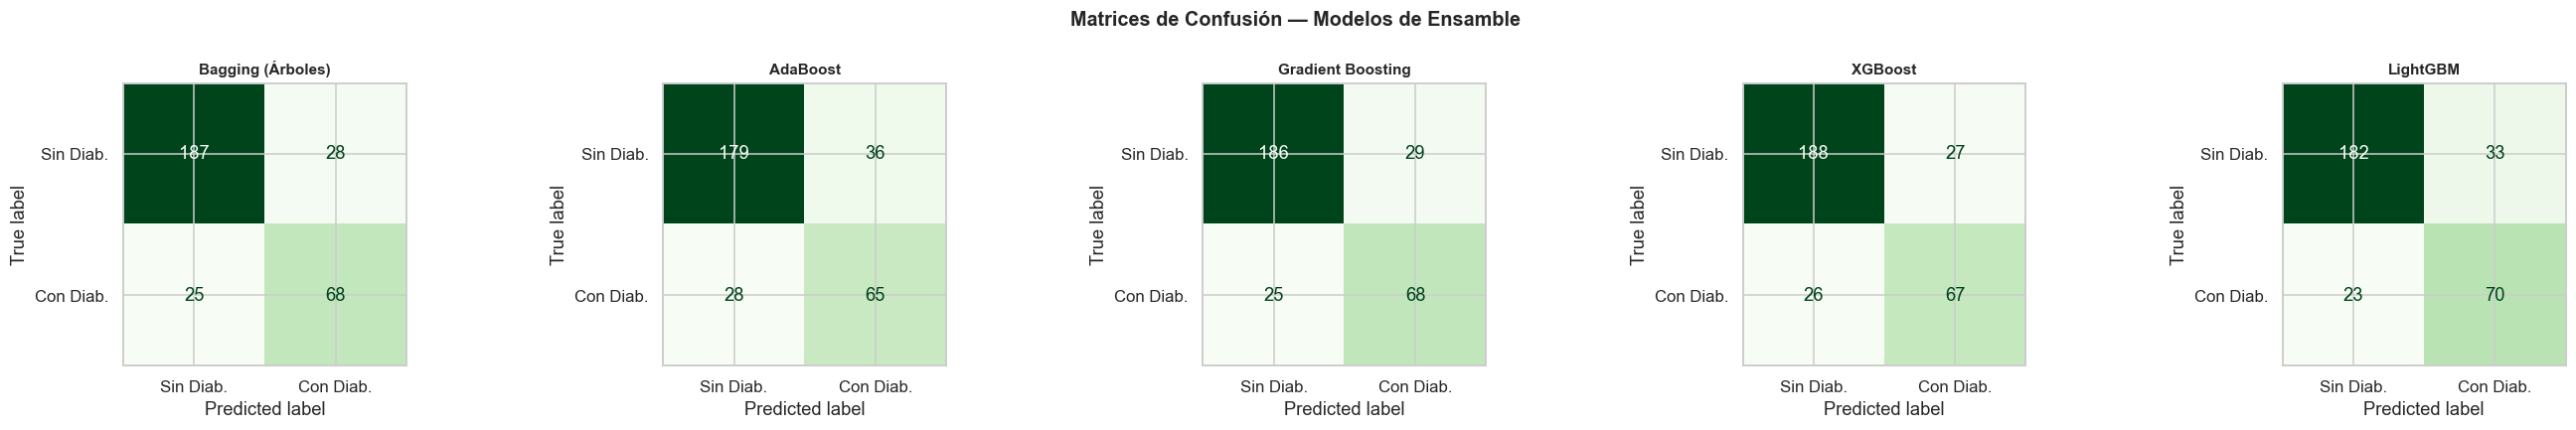

Imagen guardada: Image\17_roc_ensambles.png


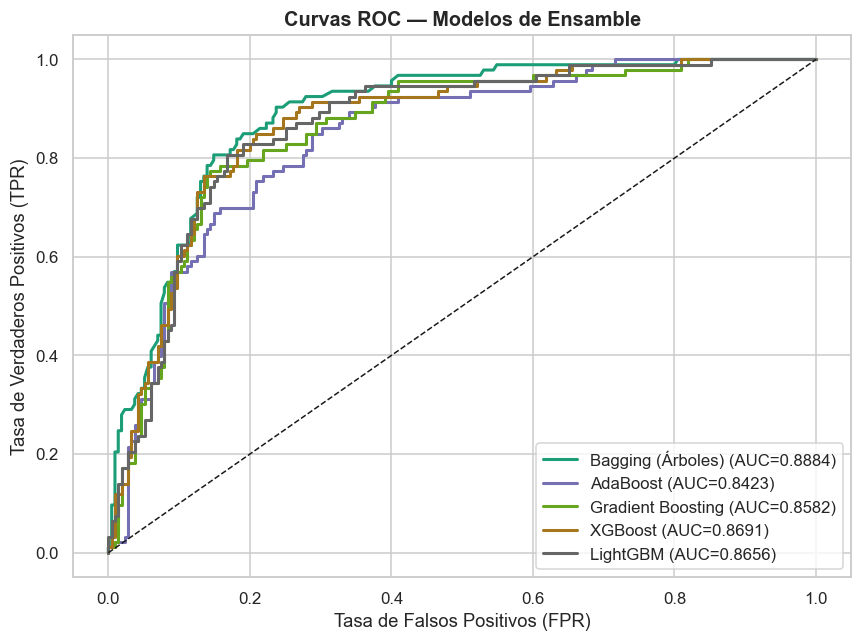

In [31]:
n_ens = len(ensambles_dict)
fig, axes = plt.subplots(1, n_ens, figsize=(5*n_ens, 4))

for ax, (nombre, modelo) in zip(axes, ensambles_dict.items()):
    y_pred = modelo.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Sin Diab.','Con Diab.']).plot(
        ax=ax, colorbar=False, cmap='Greens'
    )
    ax.set_title(nombre, fontsize=10, fontweight='bold')

plt.suptitle('Matrices de Confusión — Modelos de Ensamble', fontsize=13, fontweight='bold')
plt.tight_layout()
guardar_figura('16_matrices_confusion_ensambles', fig)
plt.show()

plt.figure(figsize=(8, 6))
colores_ens = plt.cm.Dark2(np.linspace(0, 1, n_ens))

for (nombre, modelo), color in zip(ensambles_dict.items(), colores_ens):
    y_proba = modelo.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.4f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC — Modelos de Ensamble', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
guardar_figura('17_roc_ensambles')
plt.show()

### Paso 20 · Análisis de Lift por Decil — Ensambles


  Tabla de Lift por Decil - Bagging (Árboles)


,Decil,Total_Casos,Casos_Positivos,Tasa_Exito,Lift
9,10,31,27,87.10%,2.884
8,9,31,19,61.29%,2.030
7,8,31,20,64.52%,2.137
6,7,30,13,43.33%,1.435
5,6,31,8,25.81%,0.855
4,5,31,3,9.68%,0.320
3,4,30,2,6.67%,0.221
2,3,31,0,0.00%,0.000
1,2,31,1,3.23%,0.107
0,1,31,0,0.00%,0.000



  Tabla de Lift por Decil - AdaBoost


,Decil,Total_Casos,Casos_Positivos,Tasa_Exito,Lift
9,10,31,23,74.19%,2.457
8,9,31,22,70.97%,2.350
7,8,31,17,54.84%,1.816
6,7,30,10,33.33%,1.104
5,6,31,10,32.26%,1.068
4,5,31,4,12.90%,0.427
3,4,30,1,3.33%,0.110
2,3,31,5,16.13%,0.534
1,2,31,1,3.23%,0.107
0,1,31,0,0.00%,0.000



  Tabla de Lift por Decil - Gradient Boosting


...


  Tabla de Lift por Decil - XGBoost


,Decil,Total_Casos,Casos_Positivos,Tasa_Exito,Lift
9,10,31,23,74.19%,2.457
8,9,31,21,67.74%,2.243
7,8,31,22,70.97%,2.350
6,7,30,12,40.00%,1.325
5,6,31,7,22.58%,0.748
4,5,31,1,3.23%,0.107
3,4,30,3,10.00%,0.331
2,3,31,3,9.68%,0.320
1,2,31,1,3.23%,0.107
0,1,31,0,0.00%,0.000



  Tabla de Lift por Decil - LightGBM


,Decil,Total_Casos,Casos_Positivos,Tasa_Exito,Lift
9,10,31,22,70.97%,2.350
8,9,31,21,67.74%,2.243
7,8,31,22,70.97%,2.350
6,7,30,12,40.00%,1.325
5,6,31,8,25.81%,0.855
4,5,31,3,9.68%,0.320
3,4,30,1,3.33%,0.110
2,3,31,3,9.68%,0.320
1,2,31,1,3.23%,0.107
0,1,31,0,0.00%,0.000


Imagen guardada: Image\18_lift_deciles_ensambles.png


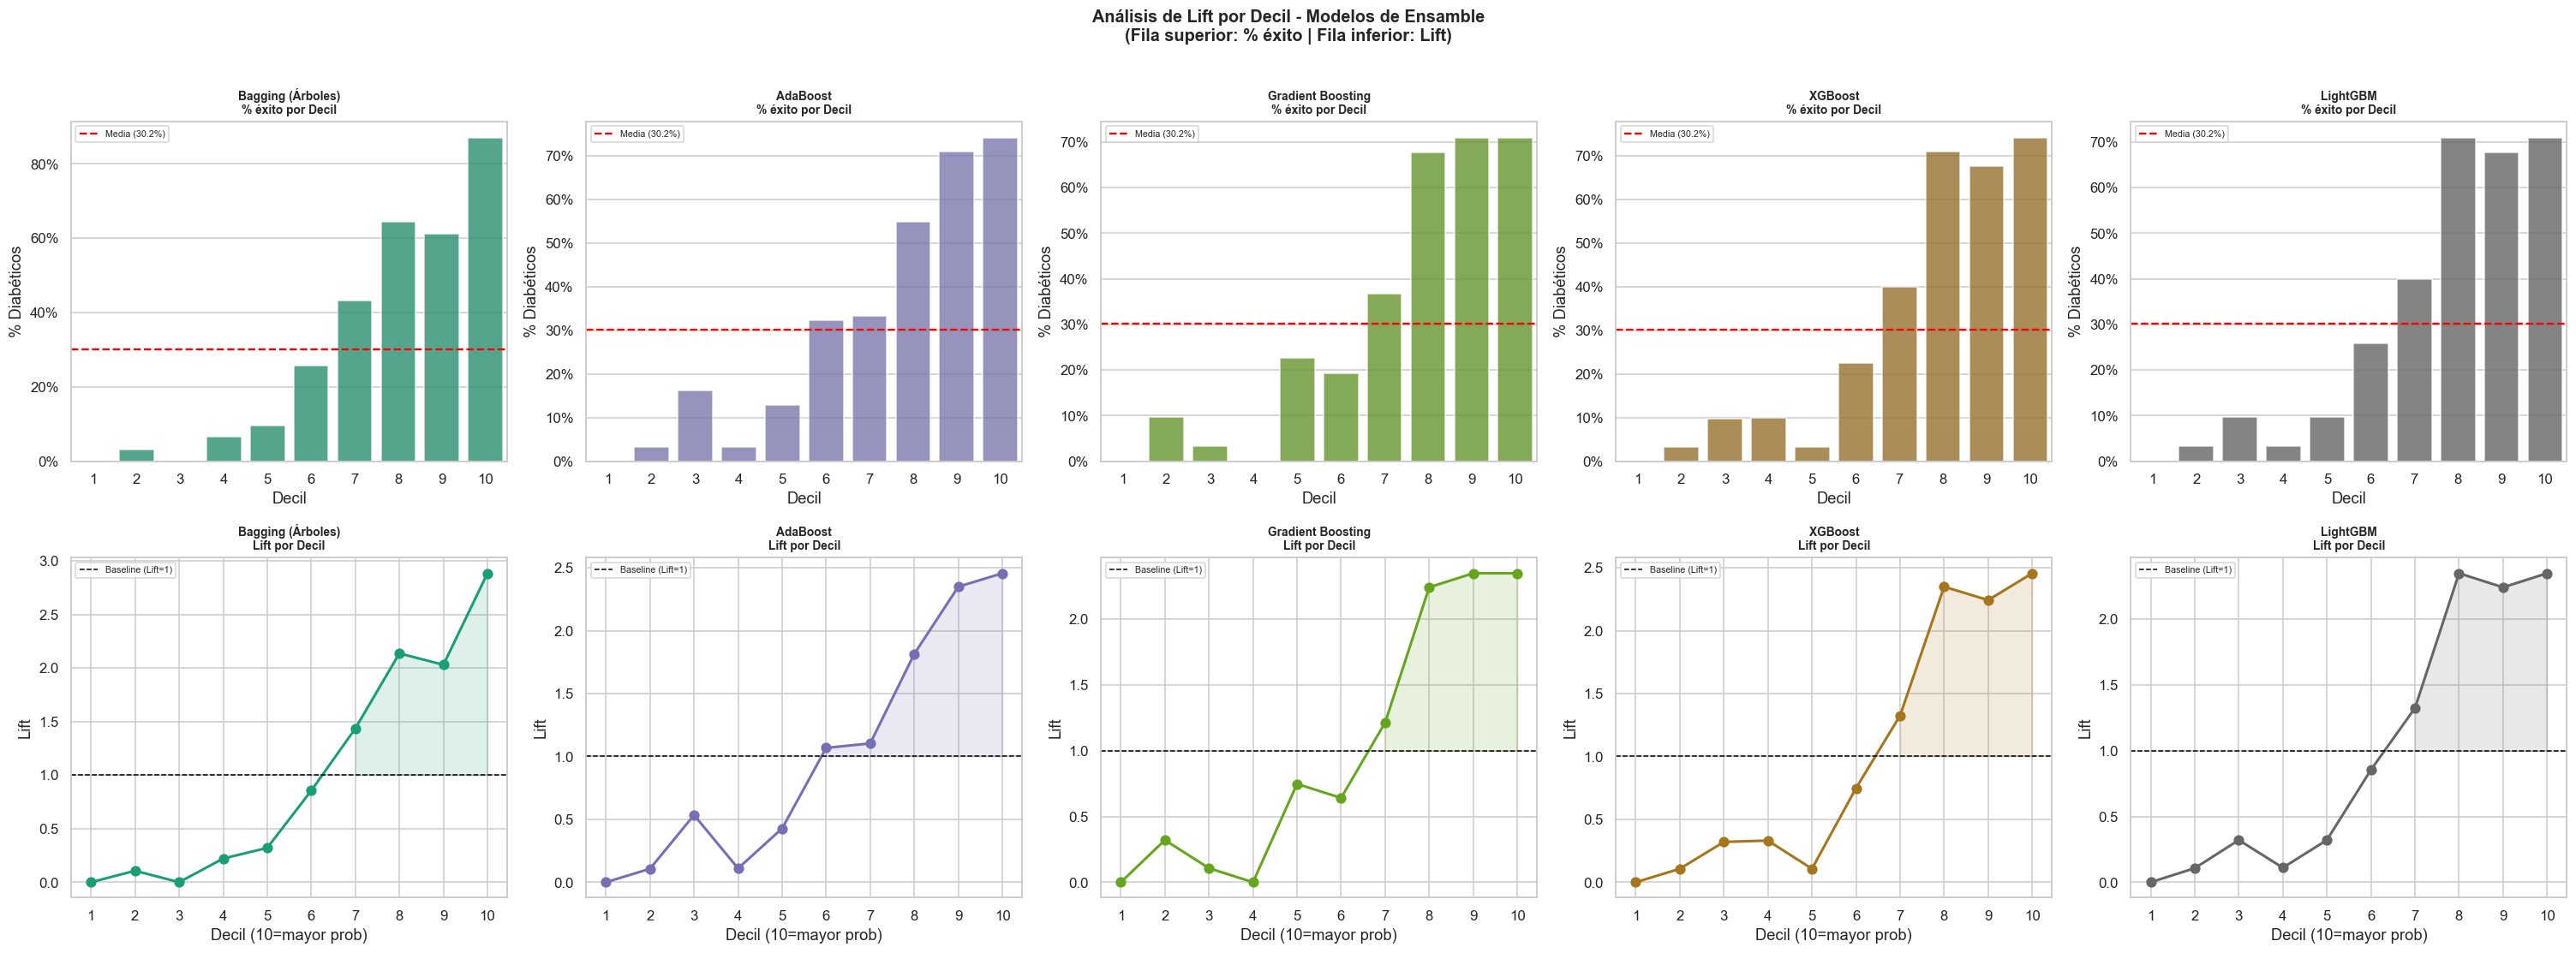

Imagen guardada: Image\19_lift_acumulado_ensambles.png


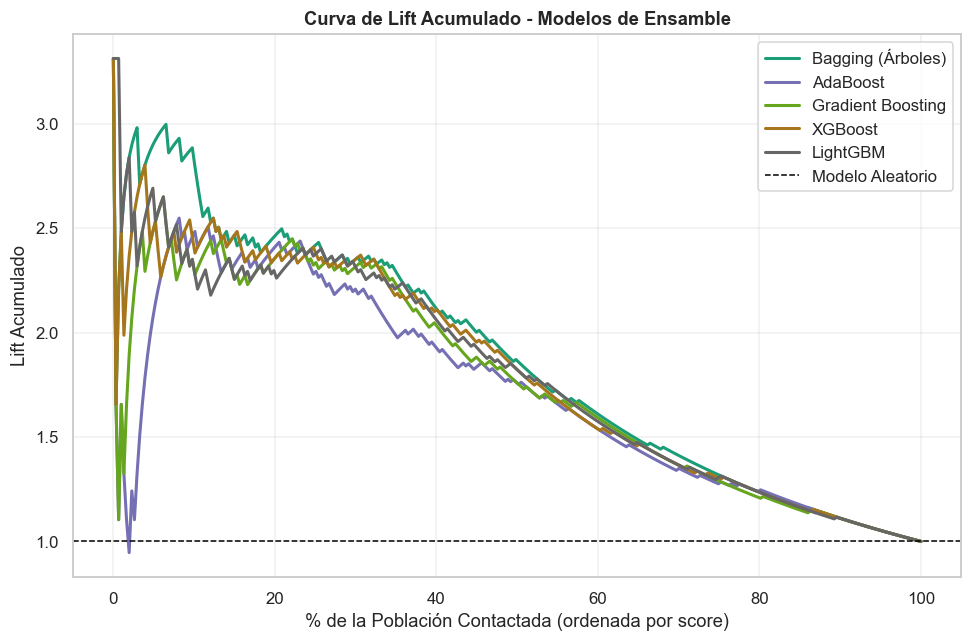

In [32]:
for nombre, modelo in ensambles_dict.items():
    tabla, _ = calcular_lift_deciles(nombre, modelo, X_test_sc, y_test)
    print(f"\n{'='*60}")
    print(f"  Tabla de Lift por Decil - {nombre}")
    print(f"{'='*60}")
    display(tabla[['Decil','Total_Casos','Casos_Positivos','Tasa_Exito','Lift']]
            .style.format({'Tasa_Exito': '{:.2%}', 'Lift': '{:.3f}'})
            .bar(subset=['Lift'], color='#5fba7d'))

fig, axes = plt.subplots(2, len(ensambles_dict), figsize=(5.5*len(ensambles_dict), 10))

for idx, (nombre, modelo) in enumerate(ensambles_dict.items()):
    tabla, tasa_global = calcular_lift_deciles(nombre, modelo, X_test_sc, y_test)
    color = colores_ens[idx]

    ax_exito = axes[0][idx]
    sns.barplot(x='Decil', y='Tasa_Exito', data=tabla, ax=ax_exito,
                color=color, alpha=0.8)
    ax_exito.axhline(tasa_global, color='red', linestyle='--', linewidth=1.5,
                     label=f'Media ({tasa_global:.1%})')
    ax_exito.set_title(f'{nombre}\n% éxito por Decil', fontsize=9, fontweight='bold')
    ax_exito.set_ylabel('% Diabéticos')
    ax_exito.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax_exito.legend(fontsize=7)

    ax_lift = axes[1][idx]
    tabla_plot = tabla.sort_values('Decil')
    ax_lift.plot(tabla_plot['Decil'].astype(str), tabla_plot['Lift'],
                 marker='o', color=color, linewidth=2, markersize=7)
    ax_lift.axhline(1, color='black', linestyle='--', linewidth=1, label='Baseline (Lift=1)')
    ax_lift.fill_between(range(len(tabla_plot)), tabla_plot['Lift'].values, 1,
                         where=tabla_plot['Lift'].values > 1, alpha=0.15, color=color)
    ax_lift.set_title(f'{nombre}\nLift por Decil', fontsize=9, fontweight='bold')
    ax_lift.set_ylabel('Lift')
    ax_lift.set_xlabel('Decil (10=mayor prob)')
    ax_lift.legend(fontsize=7)

plt.suptitle('Análisis de Lift por Decil - Modelos de Ensamble\n(Fila superior: % éxito | Fila inferior: Lift)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
guardar_figura('18_lift_deciles_ensambles', fig)
plt.show()

plt.figure(figsize=(9, 6))
for (nombre, modelo), color in zip(ensambles_dict.items(), colores_ens):
    probs = modelo.predict_proba(X_test_sc)[:, 1]
    df_res = pd.DataFrame({'Target': np.array(y_test), 'Prob': probs})
    df_res = df_res.sort_values('Prob', ascending=False).reset_index(drop=True)
    tasa_global = df_res['Target'].mean()
    cum_positivos = df_res['Target'].cumsum()
    cum_total = np.arange(1, len(df_res)+1)
    lift_acum = (cum_positivos / cum_total) / tasa_global
    x_pct = np.linspace(0, 100, len(lift_acum))
    plt.plot(x_pct, lift_acum, label=nombre, color=color, linewidth=2)

plt.axhline(1, color='black', linestyle='--', linewidth=1, label='Modelo Aleatorio')
plt.xlabel('% de la Población Contactada (ordenada por score)')
plt.ylabel('Lift Acumulado')
plt.title('Curva de Lift Acumulado - Modelos de Ensamble', fontsize=12, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
guardar_figura('19_lift_acumulado_ensambles')
plt.show()


### Paso 21 · Resumen Ejecutivo Global — Todos los Modelos

Se comparan los **5 modelos base** con los **5 modelos de ensamble**, todos tuneados con GridSearchCV (10-fold estratificada), para seleccionar el ganador global. Se reportan también **Kappa** y **Gini**.


  RESUMEN EJECUTIVO GLOBAL — TODOS LOS MODELOS


,Accuracy,Precision,Recall,F1-Score,Kappa,ROC AUC,Gini
Modelo,,,,,,,
KNN,0.7792,0.6263,0.6667,0.6458,0.4857,0.8370,0.6739
Naive Bayes,0.7695,0.5932,0.7527,0.6635,0.4919,0.8566,0.7131
SVM,0.7565,0.5918,0.6237,0.6073,0.4310,0.8073,0.6146
Regresión Logística,0.8117,0.6923,0.6774,0.6848,0.5505,0.8739,0.7478
MLP (Red Neuronal),0.7727,0.6211,0.6344,0.6277,0.4641,0.8281,0.6562
Bagging (Árboles),0.8279,0.7083,0.7312,0.7196,0.5955,0.8884,0.7769
AdaBoost,0.7922,0.6436,0.6989,0.6701,0.5188,0.8423,0.6846
Gradient Boosting,0.8247,0.7010,0.7312,0.7158,0.5891,0.8582,0.7164
XGBoost,0.8279,0.7128,0.7204,0.7166,0.5930,0.8691,0.7381


Imagen guardada: Image\20_metricas_globales_modelos.png


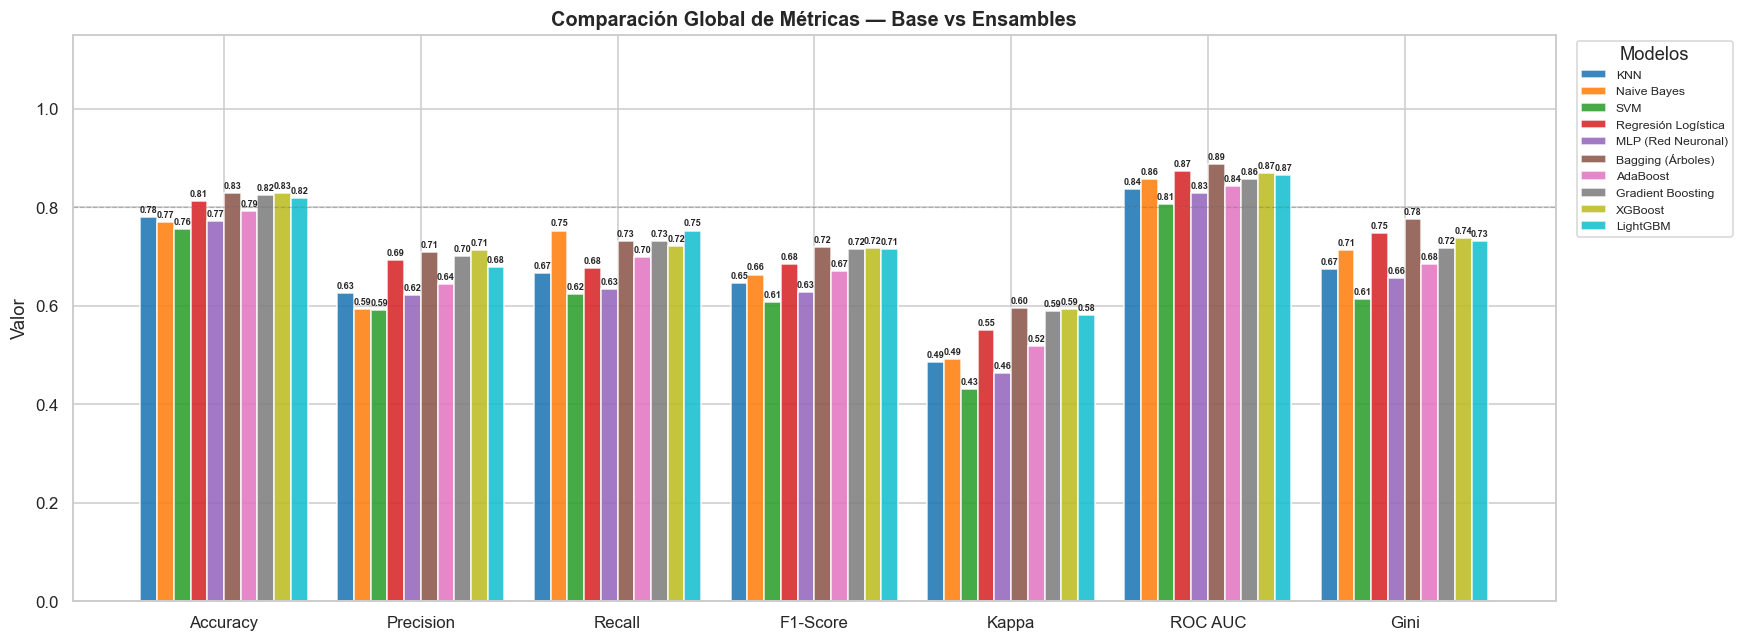


🏆 RANKING POR ROC AUC:
   🥇 1. Bagging (Árboles)          AUC=0.8884  F1=0.7196
   🥈 2. Regresión Logística        AUC=0.8739  F1=0.6848
   🥉 3. XGBoost                    AUC=0.8691  F1=0.7166
      4. LightGBM                   AUC=0.8656  F1=0.7143
      5. Gradient Boosting          AUC=0.8582  F1=0.7158
      6. Naive Bayes                AUC=0.8566  F1=0.6635
      7. AdaBoost                   AUC=0.8423  F1=0.6701
      8. KNN                        AUC=0.8370  F1=0.6458
      9. MLP (Red Neuronal)         AUC=0.8281  F1=0.6277
      10. SVM                        AUC=0.8073  F1=0.6073

✅ MODELO GANADOR GLOBAL: Bagging (Árboles)
   ROC AUC  : 0.8884
   F1-Score : 0.7196
   Accuracy : 0.8279


In [33]:
# ── Combinar tabla de métricas base + ensambles ──────────────────────────────
tabla_global = pd.concat([tabla_metricas, tabla_ensambles], axis=0)

print("\n" + "="*70)
print("  RESUMEN EJECUTIVO GLOBAL — TODOS LOS MODELOS")
print("="*70)
display(tabla_global.style
    .highlight_max(color='lightgreen', axis=0)
    .highlight_min(color='#ffcccc', axis=0)
    .format('{:.4f}')
    .set_caption("Verde = mejor valor | Rojo = peor valor por columna"))

# ── Gráfica comparativa de barras — todos los modelos ────────────────────────
metricas_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Kappa', 'ROC AUC', 'Gini']
df_plot = tabla_global[metricas_cols].T

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(metricas_cols))
n_modelos = len(df_plot.columns)
width = 0.85 / n_modelos
paleta = plt.cm.tab10(np.linspace(0, 1, n_modelos))

for i, (col, color) in enumerate(zip(df_plot.columns, paleta)):
    offset = (i - n_modelos/2 + 0.5) * width
    bars = ax.bar(x + offset, df_plot[col], width, label=col, color=color, alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=6, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metricas_cols)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor')
ax.set_title('Comparación Global de Métricas — Base vs Ensambles', fontsize=13, fontweight='bold')
ax.legend(title='Modelos', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
guardar_figura('20_metricas_globales_modelos', fig)
plt.show()

# ── Ranking por ROC AUC ──────────────────────────────────────────────────────
ranking = tabla_global.sort_values('ROC AUC', ascending=False)
print("\n🏆 RANKING POR ROC AUC:")
for i, (modelo, row) in enumerate(ranking.iterrows(), 1):
    medalla = "🥇" if i==1 else "🥈" if i==2 else "🥉" if i==3 else "  "
    print(f"   {medalla} {i}. {modelo:25s}  AUC={row['ROC AUC']:.4f}  F1={row['F1-Score']:.4f}")

# ── Modelo ganador global ────────────────────────────────────────────────────
modelos_todos = {**modelos_dict, **ensambles_dict}
mejor_global_nombre = tabla_global['ROC AUC'].idxmax()
mejor_global_obj    = modelos_todos[mejor_global_nombre]

print("\n" + "="*70)
print(f"✅ MODELO GANADOR GLOBAL: {mejor_global_nombre}")
print(f"   ROC AUC  : {tabla_global.loc[mejor_global_nombre,'ROC AUC']:.4f}")
print(f"   F1-Score : {tabla_global.loc[mejor_global_nombre,'F1-Score']:.4f}")
print(f"   Accuracy : {tabla_global.loc[mejor_global_nombre,'Accuracy']:.4f}")
print("="*70)

---
## BLOQUE 8 — Stacking: Ensamble de los 3 Mejores Modelos
### Paso 22 · StackingClassifier sobre el Top-3 del ranking global

El **Stacking** combina varios modelos base entrenados de forma independiente,
usando sus probabilidades predichas como entrada de un **meta-aprendiz**.

| Componente | Rol |
|---|---|
| Top-3 modelos por ROC AUC | Estimadores base (nivel 0) |
| Logistic Regression | Meta-aprendiz (nivel 1) |
| Validación cruzada interna (cv=10) | Genera meta-features sin data leakage |

> Los 3 modelos base se seleccionan **dinámicamente** desde `tabla_global` para garantizar que siempre se use el mejor trío disponible.

  STACKING — Top-3 Modelos Seleccionados
  🥇 1. Bagging (Árboles)               AUC = 0.8884
  🥈 2. Regresión Logística             AUC = 0.8739
  🥉 3. XGBoost                         AUC = 0.8691

Entrenando StackingClassifier (cv=10) ...
Listo.

Métrica            Valor
-------------------------
  Accuracy      0.8247
  Precision     0.7053
  Recall        0.7204
  F1-Score      0.7128
  Kappa         0.5866
  ROC AUC       0.8875
  Gini          0.7750
Imagen guardada: Image\21_stacking_matriz_roc.png


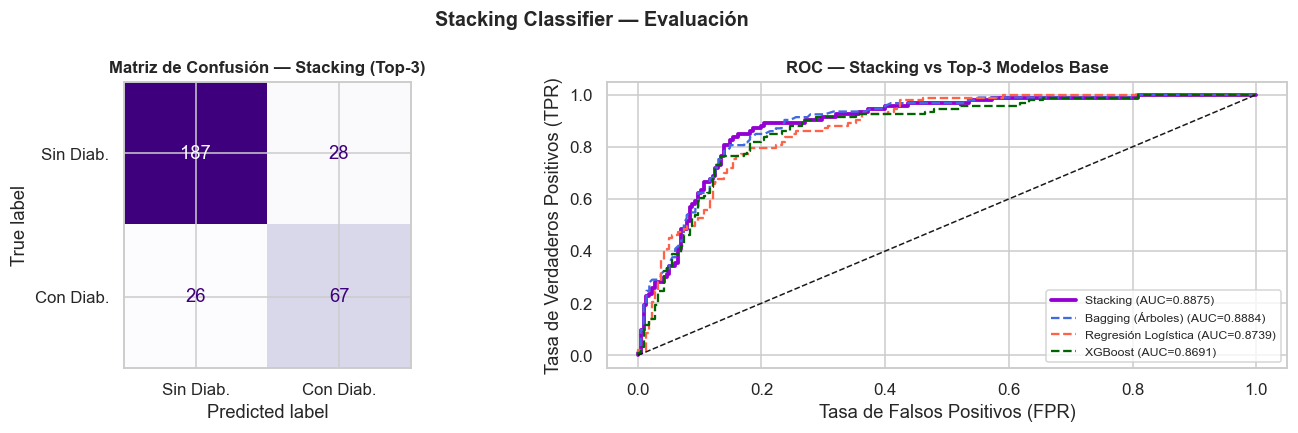


  RANKING FINAL (incluyendo Stacking)
  🥇  1. Bagging (Árboles)               AUC=0.8884  F1=0.7196
  🥈  2. Stacking (Top-3)                AUC=0.8875  F1=0.7128 ◀ NUEVO
  🥉  3. Regresión Logística             AUC=0.8739  F1=0.6848
      4. XGBoost                         AUC=0.8691  F1=0.7166
      5. LightGBM                        AUC=0.8656  F1=0.7143
      6. Gradient Boosting               AUC=0.8582  F1=0.7158
      7. Naive Bayes                     AUC=0.8566  F1=0.6635
      8. AdaBoost                        AUC=0.8423  F1=0.6701
      9. KNN                             AUC=0.8370  F1=0.6458
     10. MLP (Red Neuronal)              AUC=0.8281  F1=0.6277
     11. SVM                             AUC=0.8073  F1=0.6073


,Accuracy,Precision,Recall,F1-Score,Kappa,ROC AUC,Gini
Modelo,,,,,,,
Bagging (Árboles),0.8279,0.7083,0.7312,0.7196,0.5955,0.8884,0.7769
Stacking (Top-3),0.8247,0.7053,0.7204,0.7128,0.5866,0.8875,0.7750
Regresión Logística,0.8117,0.6923,0.6774,0.6848,0.5505,0.8739,0.7478
XGBoost,0.8279,0.7128,0.7204,0.7166,0.5930,0.8691,0.7381
LightGBM,0.8182,0.6796,0.7527,0.7143,0.5815,0.8656,0.7311
Gradient Boosting,0.8247,0.7010,0.7312,0.7158,0.5891,0.8582,0.7164
Naive Bayes,0.7695,0.5932,0.7527,0.6635,0.4919,0.8566,0.7131
AdaBoost,0.7922,0.6436,0.6989,0.6701,0.5188,0.8423,0.6846
KNN,0.7792,0.6263,0.6667,0.6458,0.4857,0.8370,0.6739


In [34]:
# ── Paso 22 · Stacking — Top-3 modelos del ranking global ────────────────────
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone

# 1. Identificar dinámicamente el Top-3 por ROC AUC
top3_nombres = tabla_global.sort_values('ROC AUC', ascending=False).head(3).index.tolist()

print("=" * 70)
print("  STACKING — Top-3 Modelos Seleccionados")
print("=" * 70)
for i, n in enumerate(top3_nombres, 1):
    medalla = ["🥇", "🥈", "🥉"][i-1]
    print(f"  {medalla} {i}. {n:30s}  AUC = {tabla_global.loc[n, 'ROC AUC']:.4f}")

# 2. Clonar los estimadores para evitar data leakage del fit anterior
def nombre_limpio(s):
    return s.replace(' ', '_').replace('(', '').replace(')', '').replace('á', 'a')

estimators_stack = [
    (nombre_limpio(n), clone(modelos_todos[n]))
    for n in top3_nombres
]

# 3. Construir y entrenar StackingClassifier
stacking_clf = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    cv=10,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False
)

print("\nEntrenando StackingClassifier (cv=10) ...")
stacking_clf.fit(X_train_sc, y_train)
print("Listo.")

# 4. Evaluar
y_pred_stack  = stacking_clf.predict(X_test_sc)
y_proba_stack = stacking_clf.predict_proba(X_test_sc)[:, 1]

acc_s   = accuracy_score(y_test, y_pred_stack)
prec_s  = precision_score(y_test, y_pred_stack, zero_division=0)
rec_s   = recall_score(y_test, y_pred_stack, zero_division=0)
f1_s    = f1_score(y_test, y_pred_stack, zero_division=0)
kappa_s = cohen_kappa_score(y_test, y_pred_stack)
auc_s   = roc_auc_score(y_test, y_proba_stack)
gini_s  = 2*auc_s - 1

print(f"\n{'Métrica':<15} {'Valor':>8}")
print("-" * 25)
for metrica, valor in [('Accuracy', acc_s), ('Precision', prec_s),
                        ('Recall', rec_s), ('F1-Score', f1_s),
                        ('Kappa', kappa_s), ('ROC AUC', auc_s), ('Gini', gini_s)]:
    print(f"  {metrica:<13} {valor:.4f}")

# 5. Agregar al ranking global extendido
fila_stacking = pd.DataFrame([{
    'Modelo'   : 'Stacking (Top-3)',
    'Accuracy' : round(acc_s, 4),
    'Precision': round(prec_s, 4),
    'Recall'   : round(rec_s, 4),
    'F1-Score' : round(f1_s, 4),
    'Kappa'    : round(kappa_s, 4),
    'ROC AUC'  : round(auc_s, 4),
    'Gini'     : round(gini_s, 4)
}]).set_index('Modelo')

tabla_global_ext = pd.concat([tabla_global, fila_stacking], axis=0)
modelos_todos['Stacking (Top-3)'] = stacking_clf

# 6. Matriz de confusión + Curva ROC comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_stack)
ConfusionMatrixDisplay(cm, display_labels=['Sin Diab.', 'Con Diab.']).plot(
    ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Matriz de Confusión — Stacking (Top-3)', fontsize=11, fontweight='bold')

# Curva ROC: Stacking vs sus 3 modelos base
fpr_s, tpr_s, _ = roc_curve(y_test, y_proba_stack)
axes[1].plot(fpr_s, tpr_s, color='darkviolet', linewidth=2.5,
             label=f'Stacking (AUC={auc_s:.4f})')

colores_top3 = ['royalblue', 'tomato', 'darkgreen']
for nombre, color in zip(top3_nombres, colores_top3):
    y_pb = modelos_todos[nombre].predict_proba(X_test_sc)[:, 1]
    fpr_b, tpr_b, _ = roc_curve(y_test, y_pb)
    auc_b = roc_auc_score(y_test, y_pb)
    axes[1].plot(fpr_b, tpr_b, color=color, linewidth=1.5, linestyle='--',
                 label=f'{nombre} (AUC={auc_b:.4f})')

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('ROC — Stacking vs Top-3 Modelos Base', fontsize=11, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)

plt.suptitle('Stacking Classifier — Evaluación', fontsize=13, fontweight='bold')
plt.tight_layout()
guardar_figura('21_stacking_matriz_roc', fig)
plt.show()

# 7. Ranking final actualizado
print("\n" + "=" * 70)
print("  RANKING FINAL (incluyendo Stacking)")
print("=" * 70)
ranking_ext = tabla_global_ext.sort_values('ROC AUC', ascending=False)
for i, (modelo, row) in enumerate(ranking_ext.iterrows(), 1):
    medalla = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    marca   = " ◀ NUEVO" if modelo == 'Stacking (Top-3)' else ""
    print(f"  {medalla} {i:2d}. {modelo:30s}  AUC={row['ROC AUC']:.4f}  F1={row['F1-Score']:.4f}{marca}")

# 8. Tabla comparativa estilizada
display(tabla_global_ext.sort_values('ROC AUC', ascending=False)
        .style
        .highlight_max(color='lightgreen', axis=0)
        .highlight_min(color='#ffcccc', axis=0)
        .format('{:.4f}')
        .set_caption("Verde = mejor | Rojo = peor · ordenado por ROC AUC"))

---
## BLOQUE 9 — Interpretabilidad con SHAP
### Paso 23 · Explicación del mejor modelo global

**SHAP (SHapley Additive exPlanations)** descompone cada predicción en la contribución individual
de cada variable. Permite responder:

- ¿Qué variables son más importantes globalmente?
- ¿Cómo aporta cada variable (suma o resta riesgo) en cada predicción?
- ¿Hay interacciones no lineales?

**Estrategia de explainer según el modelo ganador:**

| Tipo de modelo | Explainer usado | Velocidad |
|---|---|---|
| Árboles soportados (XGBoost, LightGBM, Gradient Boosting) | `TreeExplainer` | Rápido |
| Resto (Naive Bayes, SVM, MLP, KNN, AdaBoost, Bagging, Stacking) | `KernelExplainer` (muestra reducida) | Moderado |

> `TreeExplainer` no soporta `AdaBoostClassifier` ni `BaggingClassifier` de sklearn. Por eso el análisis detallado con `TreeExplainer` se hace sobre el **mejor árbol soportado**, y si el ganador global no es uno de ellos, se añade `KernelExplainer` sobre el ganador para validar la importancia global.

  SHAP - Modelo ganador global: Bagging (Árboles)
  ROC AUC = 0.8884

El ganador no es compatible con TreeExplainer; se explica con KernelExplainer.
Background: 80 muestras | Instancias explicadas: 40

Importancia global SHAP - Bagging (Árboles)
Imagen guardada: Image\22_ganador_importancia_global_shap.png


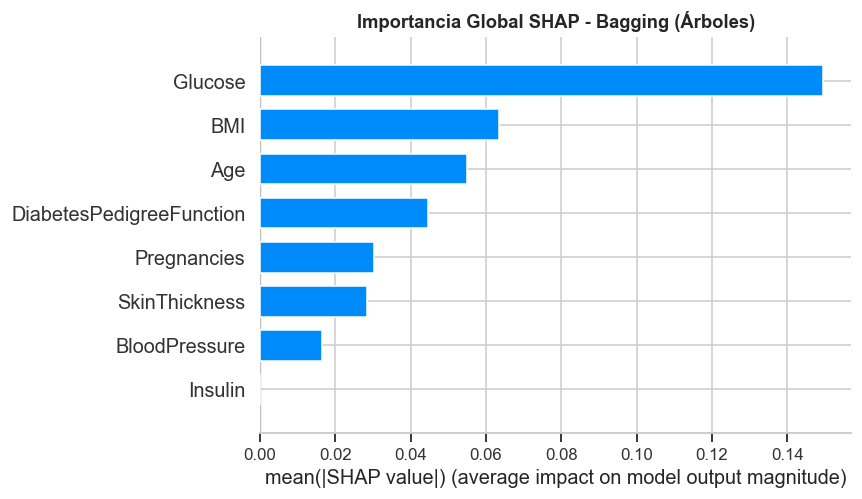


Distribución SHAP - Bagging (Árboles)
Imagen guardada: Image\22_ganador_beeswarm_shap.png


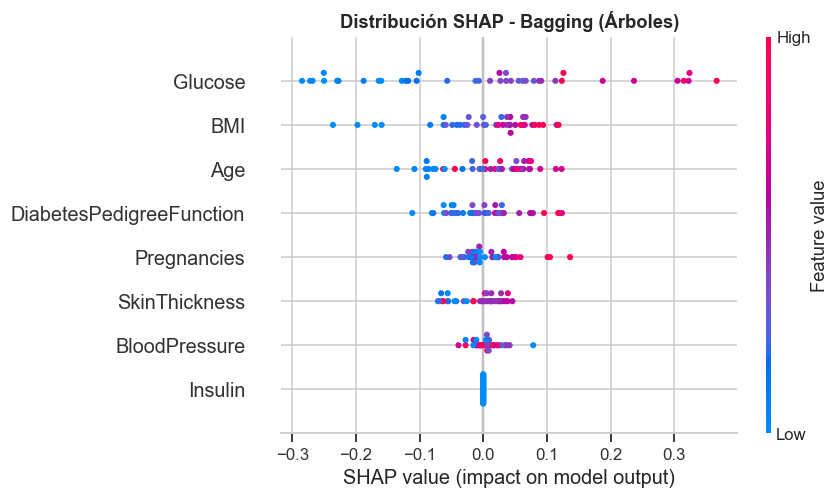


Ranking de variables por impacto SHAP del ganador:


,Variable,SHAP_medio
0,Glucose,0.1496
1,BMI,0.0634
2,Age,0.0550
3,DiabetesPedigreeFunction,0.0445
4,Pregnancies,0.0304
5,SkinThickness,0.0284
6,BloodPressure,0.0165
7,Insulin,0.0000



  SHAP complementario con TreeExplainer: XGBoost
  Se incluye porque TreeExplainer da gráficos más detallados para modelos de árbol compatibles.

Importancia global SHAP - XGBoost
Imagen guardada: Image\23_complemento_arbol_importancia_global_shap.png


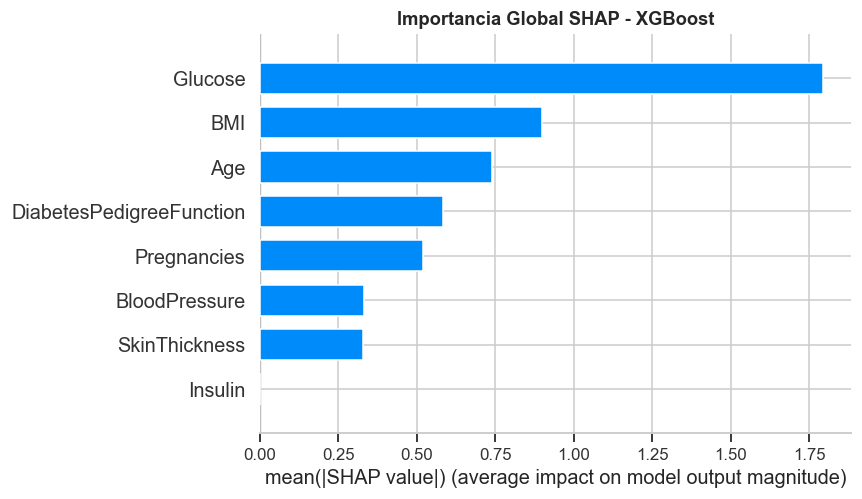


Distribución SHAP - XGBoost
Imagen guardada: Image\23_complemento_arbol_beeswarm_shap.png


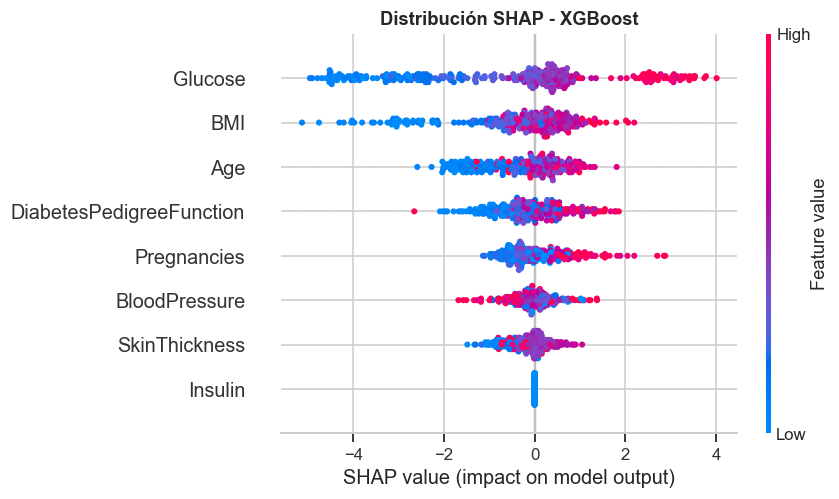


Comparación de importancia SHAP: Bagging (Árboles) vs XGBoost


,Variable,Bagging (Árboles),XGBoost
0,Glucose,0.1496,1.7939
1,BMI,0.0634,0.8987
2,Age,0.0550,0.7384
3,DiabetesPedigreeFunction,0.0445,0.5843
4,Pregnancies,0.0304,0.5201
5,SkinThickness,0.0284,0.3292
6,BloodPressure,0.0165,0.3328
7,Insulin,0.0000,0.0000



  CONCLUSIÓN SHAP
  Modelo ganador global : Bagging (Árboles)
  ROC AUC               : 0.8884
  Variable más influyente del ganador: Glucose


In [35]:
import shap

MODELOS_ARBOL = {'XGBoost', 'LightGBM', 'Gradient Boosting'}
X_train_df = pd.DataFrame(X_train_sc, columns=features)
X_test_df = pd.DataFrame(X_test_sc, columns=features)

mejor_final_nombre = tabla_global_ext['ROC AUC'].idxmax()
mejor_final_obj = modelos_todos[mejor_final_nombre]

print('=' * 70)
print(f'  SHAP - Modelo ganador global: {mejor_final_nombre}')
print(f"  ROC AUC = {tabla_global_ext.loc[mejor_final_nombre, 'ROC AUC']:.4f}")
print('=' * 70)


def shap_clase_positiva(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]
    if hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    return shap_values


def graficar_shap_global(shap_values, datos, nombre_modelo, prefijo):
    sv = shap_clase_positiva(shap_values)

    print(f'\nImportancia global SHAP - {nombre_modelo}')
    shap.summary_plot(sv, datos, plot_type='bar', feature_names=features, show=False)
    plt.title(f'Importancia Global SHAP - {nombre_modelo}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    guardar_figura(f'{prefijo}_importancia_global_shap')
    plt.show()

    print(f'\nDistribución SHAP - {nombre_modelo}')
    shap.summary_plot(sv, datos, feature_names=features, show=False)
    plt.title(f'Distribución SHAP - {nombre_modelo}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    guardar_figura(f'{prefijo}_beeswarm_shap')
    plt.show()

    importancia = pd.DataFrame({
        'Variable': features,
        'SHAP_medio': np.abs(sv).mean(axis=0)
    }).sort_values('SHAP_medio', ascending=False).reset_index(drop=True)
    return sv, importancia


if mejor_final_nombre in MODELOS_ARBOL:
    explainer_ganador = shap.TreeExplainer(mejor_final_obj)
    shap_ganador = explainer_ganador.shap_values(X_test_df)
    sv_ganador, imp_ganador = graficar_shap_global(
        shap_ganador, X_test_df, mejor_final_nombre, '22_ganador'
    )

    probs_ganador = mejor_final_obj.predict_proba(X_test_sc)[:, 1]
    idx_max = int(np.argmax(probs_ganador))
    ev = explainer_ganador.expected_value
    if isinstance(ev, (list, np.ndarray)):
        ev = ev[1] if len(np.atleast_1d(ev)) > 1 else float(np.atleast_1d(ev)[0])

    print(f'\nExplicación local - Paciente #{idx_max}')
    print(f'Probabilidad estimada ({mejor_final_nombre}): {probs_ganador[idx_max]:.2%}')
    shap.force_plot(ev, sv_ganador[idx_max, :], X_test_df.iloc[idx_max, :],
                    feature_names=features, matplotlib=True, show=False)
    plt.title(f'Force Plot SHAP - Paciente #{idx_max} ({mejor_final_nombre})',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    guardar_figura('24_ganador_force_plot_shap')
    plt.show()

    top_var = imp_ganador.iloc[0]['Variable']
    shap.dependence_plot(top_var, sv_ganador, X_test_df, feature_names=features, show=False)
    plt.title(f'SHAP Dependence - {top_var}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    guardar_figura('25_ganador_dependence_shap')
    plt.show()

else:
    print('\nEl ganador no es compatible con TreeExplainer; se explica con KernelExplainer.')
    n_bg = min(80, len(X_train_df))
    n_expl = min(40, len(X_test_df))
    X_bg = X_train_df.sample(n=n_bg, random_state=42)
    X_ex = X_test_df.sample(n=n_expl, random_state=42).reset_index(drop=True)

    predict_fn = lambda x: mejor_final_obj.predict_proba(np.asarray(x))[:, 1]
    print(f'Background: {n_bg} muestras | Instancias explicadas: {n_expl}')
    kernel_exp = shap.KernelExplainer(predict_fn, X_bg)
    shap_ganador = kernel_exp.shap_values(X_ex, nsamples=200, silent=True)
    sv_ganador, imp_ganador = graficar_shap_global(
        shap_ganador, X_ex, mejor_final_nombre, '22_ganador'
    )

print('\nRanking de variables por impacto SHAP del ganador:')
display(imp_ganador.style
        .format({'SHAP_medio': '{:.4f}'})
        .bar(subset=['SHAP_medio'], color='#7e57c2')
        .background_gradient(subset=['SHAP_medio'], cmap='Purples'))

top_var_ganador = imp_ganador.iloc[0]['Variable']

if mejor_final_nombre not in MODELOS_ARBOL:
    mejor_arbol_nombre = (
        tabla_global_ext[tabla_global_ext.index.isin(MODELOS_ARBOL)]
        .sort_values('ROC AUC', ascending=False)
        .index[0]
    )
    mejor_arbol_obj = modelos_todos[mejor_arbol_nombre]

    print('\n' + '=' * 70)
    print(f'  SHAP complementario con TreeExplainer: {mejor_arbol_nombre}')
    print('  Se incluye porque TreeExplainer da gráficos más detallados para modelos de árbol compatibles.')
    print('=' * 70)

    explainer_tree = shap.TreeExplainer(mejor_arbol_obj)
    shap_tree = explainer_tree.shap_values(X_test_df)
    sv_tree, imp_tree = graficar_shap_global(
        shap_tree, X_test_df, mejor_arbol_nombre, '23_complemento_arbol'
    )

    imp_comp = pd.DataFrame({
        'Variable': features,
        mejor_final_nombre: imp_ganador.set_index('Variable').loc[features, 'SHAP_medio'].values,
        mejor_arbol_nombre: imp_tree.set_index('Variable').loc[features, 'SHAP_medio'].values
    }).sort_values(mejor_final_nombre, ascending=False).reset_index(drop=True)

    print(f'\nComparación de importancia SHAP: {mejor_final_nombre} vs {mejor_arbol_nombre}')
    display(imp_comp.style
            .format({mejor_final_nombre: '{:.4f}', mejor_arbol_nombre: '{:.4f}'})
            .background_gradient(subset=[mejor_final_nombre], cmap='Purples')
            .background_gradient(subset=[mejor_arbol_nombre], cmap='Oranges'))

print('\n' + '=' * 70)
print('  CONCLUSIÓN SHAP')
print('=' * 70)
print(f'  Modelo ganador global : {mejor_final_nombre}')
print(f"  ROC AUC               : {tabla_global_ext.loc[mejor_final_nombre, 'ROC AUC']:.4f}")
print(f'  Variable más influyente del ganador: {top_var_ganador}')
print('=' * 70)


---
## BLOQUE 10 — Exportación del Modelo Final
### Paso 24 · Guardar el mejor modelo + preprocesamiento

Se exporta un **artefacto completo** a `mejor_modelo_diabetes.pkl`. No basta con guardar el modelo: la data nueva debe pasar por **el mismo preprocesamiento del train** (ceros→mediana, winsorizing, log1p, RobustScaler), así que el artefacto incluye todos esos parámetros.

> Para probar el modelo con data nueva → abrir **`PruebaModelo.ipynb`**.

In [36]:
import joblib
from datetime import datetime

mejor_final_nombre = tabla_global_ext['ROC AUC'].idxmax()
mejor_final_obj    = modelos_todos[mejor_final_nombre]

artefacto = {
    'modelo_nombre'      : mejor_final_nombre,
    'modelo'             : mejor_final_obj,
    'features'           : features,
    'cols_ceros'         : cols_ceros,
    'medianas_imputacion': {c: float(v) for c, v in medianas_imput.items()},
    'limites_iqr'        : {c: (float(lo), float(hi)) for c, (lo, hi) in limites_iqr.items()},
    'cols_log1p'         : cols_sesgadas,
    'scaler'             : scaler,
    'metricas_test'      : tabla_global_ext.loc[mejor_final_nombre].to_dict(),
    'fecha_export'       : datetime.now().strftime('%Y-%m-%d %H:%M'),
}

joblib.dump(artefacto, 'mejor_modelo_diabetes.pkl')

print('=' * 60)
print('  ARTEFACTO EXPORTADO -> mejor_modelo_diabetes.pkl')
print('=' * 60)
print(f"  Modelo   : {mejor_final_nombre}")
print(f"  ROC AUC  : {artefacto['metricas_test']['ROC AUC']:.4f}")
print(f"  F1-Score : {artefacto['metricas_test']['F1-Score']:.4f}")
print(f"  Features : {len(features)}")
print(f"  Fecha    : {artefacto['fecha_export']}")
print('=' * 60)
print('\nPara probarlo con data nueva: abrir PruebaModelo.ipynb')


  ARTEFACTO EXPORTADO -> mejor_modelo_diabetes.pkl
  Modelo   : Bagging (Árboles)
  ROC AUC  : 0.8884
  F1-Score : 0.7196
  Features : 8
  Fecha    : 2026-07-03 17:03

Para probarlo con data nueva: abrir PruebaModelo.ipynb
